# Imports

In [1]:
import json
import time

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# General Information

In [2]:
data_dir = Path("data/")
csv_files = sorted(data_dir.glob("*.csv"))

df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)

In [3]:
df.shape

(16232943, 80)

In [4]:
print(f"Number of Rows (Samples): {df.shape[0]}")
print(f"Number of Columns (Features): {df.shape[1]}")

Number of Rows (Samples): 16232943
Number of Columns (Features): 80


In [5]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553.0,3773.0,202.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38.0,0.0,38.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086.0,10527.0,385.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0.0,0.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285.0,6141.0,517.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [6]:
df.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16232943 entries, 0 to 16232942
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           int64  
 1   Protocol           int64  
 2   Timestamp          str    
 3   Flow Duration      int64  
 4   Tot Fwd Pkts       int64  
 5   Tot Bwd Pkts       int64  
 6   TotLen Fwd Pkts    float64
 7   TotLen Bwd Pkts    float64
 8   Fwd Pkt Len Max    float64
 9   Fwd Pkt Len Min    float64
 10  Fwd Pkt Len Mean   float64
 11  Fwd Pkt Len Std    float64
 12  Bwd Pkt Len Max    float64
 13  Bwd Pkt Len Min    float64
 14  Bwd Pkt Len Mean   float64
 15  Bwd Pkt Len Std    float64
 16  Flow Byts/s        float64
 17  Flow Pkts/s        float64
 18  Flow IAT Mean      float64
 19  Flow IAT Std       float64
 20  Flow IAT Max       float64
 21  Flow IAT Min       float64
 22  Fwd IAT Tot        float64
 23  Fwd IAT Mean       float64
 24  Fwd IAT Std        float64
 25  Fwd IAT Max        float64


Create new column with shorthand labels and map them to original labels

In [8]:
df['Label'].value_counts()

Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64

In [9]:
df['Label'].unique()

<StringArray>
[                  'Benign',                      'Bot',
 'DoS attacks-SlowHTTPTest',         'DoS attacks-Hulk',
         'Brute Force -Web',         'Brute Force -XSS',
            'SQL Injection',   'DDoS attacks-LOIC-HTTP',
            'Infilteration',    'DoS attacks-GoldenEye',
    'DoS attacks-Slowloris',           'FTP-BruteForce',
           'SSH-Bruteforce',     'DDOS attack-LOIC-UDP',
         'DDOS attack-HOIC']
Length: 15, dtype: str

In [10]:
label_map = {
    'Benign': 'Benign',
    'Bot': 'Bot',
    'DoS attacks-SlowHTTPTest': 'SlowHTTPTest',
    'DoS attacks-Hulk': 'Hulk',
    'Brute Force -Web': 'Web',
    'Brute Force -XSS': 'XSS',
    'SQL Injection': 'SQL',
    'DDoS attacks-LOIC-HTTP': 'LOIC_HTTP',
    'Infilteration': 'Infiltration',   # note: original dataset misspells this
    'DoS attacks-GoldenEye': 'GoldenEye',
    'DoS attacks-Slowloris': 'Slowloris',
    'FTP-BruteForce': 'FTP',
    'SSH-Bruteforce': 'SSH',
    'DDOS attack-LOIC-UDP': 'LOIC_UDP',
    'DDOS attack-HOIC': 'HOIC',
}

df['Label_Short'] = df['Label'].map(label_map)

In [11]:
assert df['Label_Short'].isna().sum() == 0, "Unmapped labels found!"

In [12]:
unmatched = df.loc[df['Label_Short'].isna(), 'Label'].unique()

print(f"Number of unmatched labels: {len(unmatched)}")

Number of unmatched labels: 0


# Plots

## Log Scale

Show class distribution in this dataset

In [13]:
def log_scale(plot_data, title, xlabel, ylabel):
    """Draw a class distribution log scale from provided plot_data"""
    x, y = [[] for z in range(2)]
    for i in plot_data.index:
        x.append(i)
        y.append(plot_data[i])
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.grid(
        True,
        alpha=0.3
    )
    ax.set_yscale("log")  # Convert y-axis to logarithmic scale
    ax.plot(
        x,
        y,
        "o-",
        color="green"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.tight_layout()
    plt.xticks(rotation=90)
    plt.title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )
    plt.show()
    fig.savefig(
        f"images/{title}.png",
        bbox_inches="tight"
    )
    fig.clear()
    plt.close(fig)

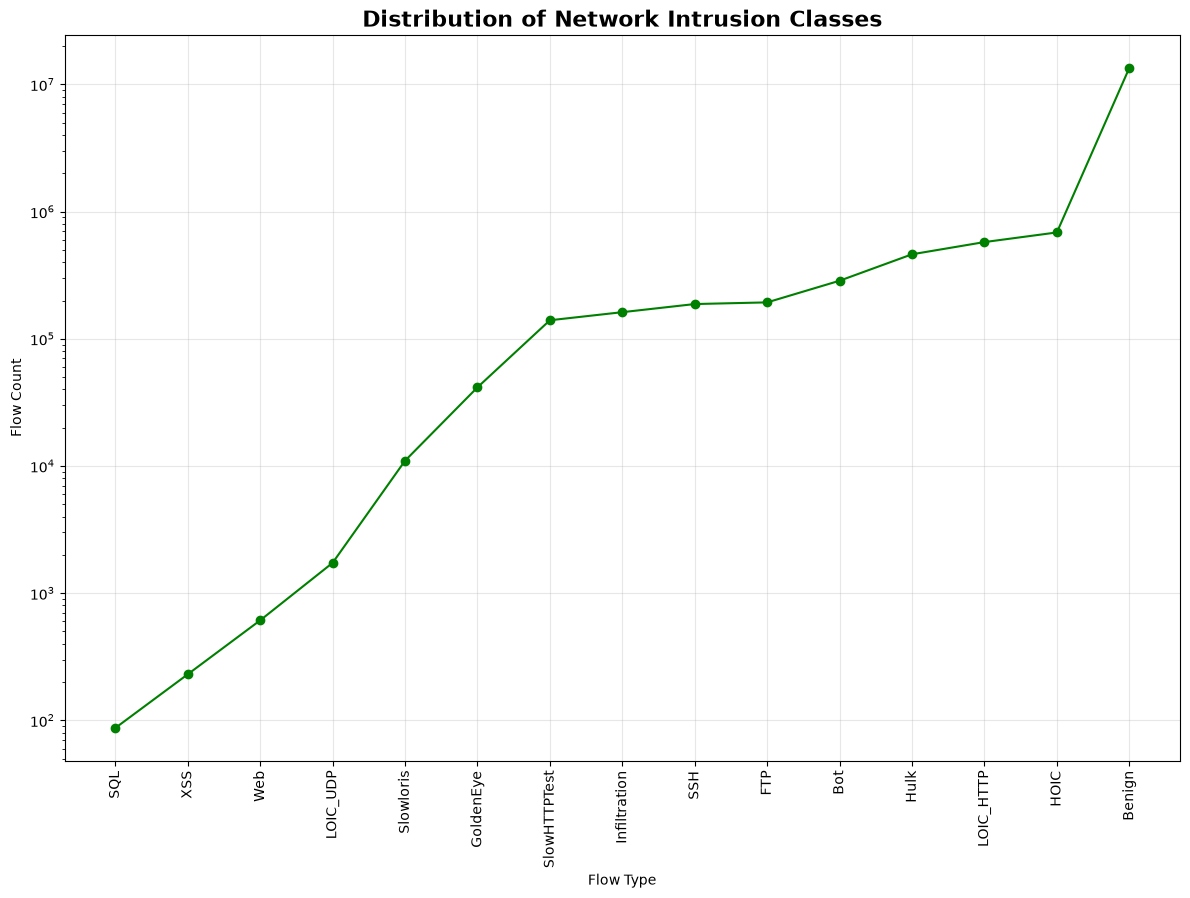

CPU times: user 2.29 s, sys: 32.7 ms, total: 2.32 s
Wall time: 2.45 s


In [14]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes",
    "Flow Type",
    "Flow Count"
)

## Pie Chart

Show ratio between Benign and Malicious flows, available in CSE-CIC-IDS2018

In [15]:
def format_class_data(df, count = 0):
    """Format dataframe into binary classification of benign and malicious"""
    for x in df.index:
        if x != "Benign":
            count += df[x]

    labels = ["Benign", "Malicious"]
    values = [df["Benign"], count]

    return labels, values

In [16]:
def pie_plot(labels, values, title):
    """Pie plot to show benign vs malicious flow record distribution"""
    plt.clf() # Clear canvas before plottting
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.tight_layout()
    plt.title(label=f"{title}", fontsize = 16, fontweight="bold")
    ax.pie(values, labels=labels, autopct='%1.0f%%',
           wedgeprops = {"edgecolor": "black",
                         "linewidth": 1,
                         "antialiased": True})
    ax.legend()
    fig.savefig(f"images/{title}.png", bbox_inches="tight")

CPU times: user 1.47 s, sys: 7.44 ms, total: 1.48 s
Wall time: 1.5 s


<Figure size 640x480 with 0 Axes>

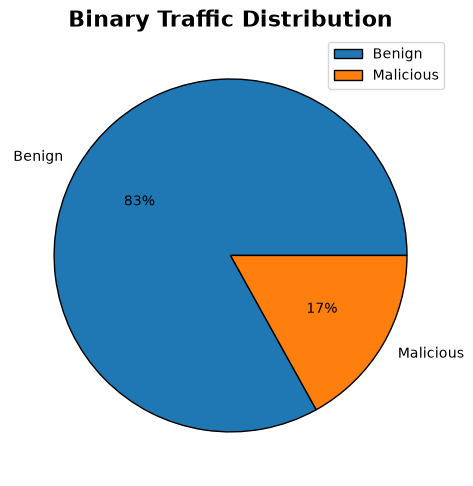

In [17]:
%%time

labels, values = format_class_data(df['Label_Short'].value_counts())

pie_plot(
    labels,
    values,
    "Binary Traffic Distribution"
)

## Protocol Chart

Chart of network protocols for which the flows are initiated

0 - protocol not assigned (possibly ICMP)<br/>
6 - TCP<br/>
17 - UDP

In [18]:
df['Protocol'].unique()

array([ 6,  0, 17])

In [19]:
df['Protocol'].value_counts()

Protocol
6     11800335
17     4194295
0       238313
Name: count, dtype: int64

In [20]:
def format_protocol_data(df, labels = [], values = []):
    """Format dataframe into binary classification of benign and malicious"""
    for x in df.index:
        if x == 0:
            labels.append("Unassigned")
        elif x == 6:
            labels.append("TCP")
        elif x == 17:
            labels.append("UDP")
        values.append(df[x])

    return labels, values

CPU times: user 196 ms, sys: 3.07 ms, total: 199 ms
Wall time: 223 ms


<Figure size 640x480 with 0 Axes>

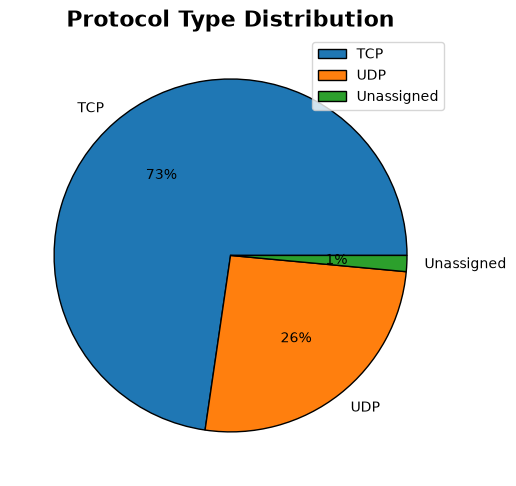

In [21]:
%%time

labels, values = format_protocol_data(df['Protocol'].value_counts())

pie_plot(
    labels,
    values,
    "Protocol Type Distribution"
)

# Cleaning Data

Objectives include:
1. Delete session info (Dst Port, Timestamp).
2. Delete rows with columns containing Infinity / NaN values.
3. Remove duplicated rows.

## Delete Session Info

Delete columns that have session info of flow data collection (Dst Port, Timestamp)

In [22]:
print(f"Column count before deletion: {len(df.columns)}")

Column count before deletion: 81


In [23]:
%%time

df.drop(['Dst Port', 'Timestamp'], axis=1, inplace=True)

CPU times: user 143 ms, sys: 11.9 ms, total: 155 ms
Wall time: 154 ms


In [24]:
print(f"Column count after deletion: {len(df.columns)}")

Column count after deletion: 79


## Dealing With Missing Values

Analyze the dataset for rows that contain NaN or Infinity values

In [25]:
%%time

nan_values = {key: value for key, value in df.isna().sum().items() if value > 0}

print(nan_values)

{'Flow Byts/s': 59721}
CPU times: user 2.39 s, sys: 679 μs, total: 2.39 s
Wall time: 2.39 s


Filter for infinity values and replace them as NaN

In [26]:
%%time

df.replace([np.inf, -np.inf], np.nan, inplace=True)

CPU times: user 3.17 s, sys: 3.79 s, total: 6.96 s
Wall time: 6.98 s


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label_Short
0,6,141385,9,7,553.0,3773.0,202.0,0.0,61.444444,87.534438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,6,281,2,1,38.0,0.0,38.0,0.0,19.000000,26.870058,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,6,279824,11,15,1086.0,10527.0,385.0,0.0,98.727273,129.392497,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,6,132,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,6,274016,9,13,1285.0,6141.0,517.0,0.0,142.777778,183.887722,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16232938,6,3,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration
16232939,6,2,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration
16232940,6,732728,2,2,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
16232941,6,22,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration


Updated list of NaN values

In [27]:
%%time

nan_values = {key: value for key, value in df.isna().sum().items() if value > 0}

print(nan_values)

{'Flow Byts/s': 95760, 'Flow Pkts/s': 95760}
CPU times: user 2.42 s, sys: 4.65 ms, total: 2.43 s
Wall time: 2.42 s


Create a bar plot to visualize NaN data

In [28]:
def nan_plot(_dict, title, xlabel, ylabel):
    """Bar plot for NaN values"""
    bar_labels = [_dict['Flow Byts/s'], _dict['Flow Pkts/s']]

    fig, ax = plt.subplots(figsize=(10,10))
    ax.grid(
        True,
        alpha=0.3
    )
    ax.bar(
        _dict.keys(),
        _dict.values(),
        zorder=3
    )
    for container in ax.containers:
        ax.bar_label(container, labels=bar_labels)
    ax.set_title(
        f"{title}",
        fontsize=16,
        fontweight="bold"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.savefig(
        f"images/{title}.png",
        bbox_inches="tight"
    )

CPU times: user 135 ms, sys: 5.09 ms, total: 141 ms
Wall time: 140 ms


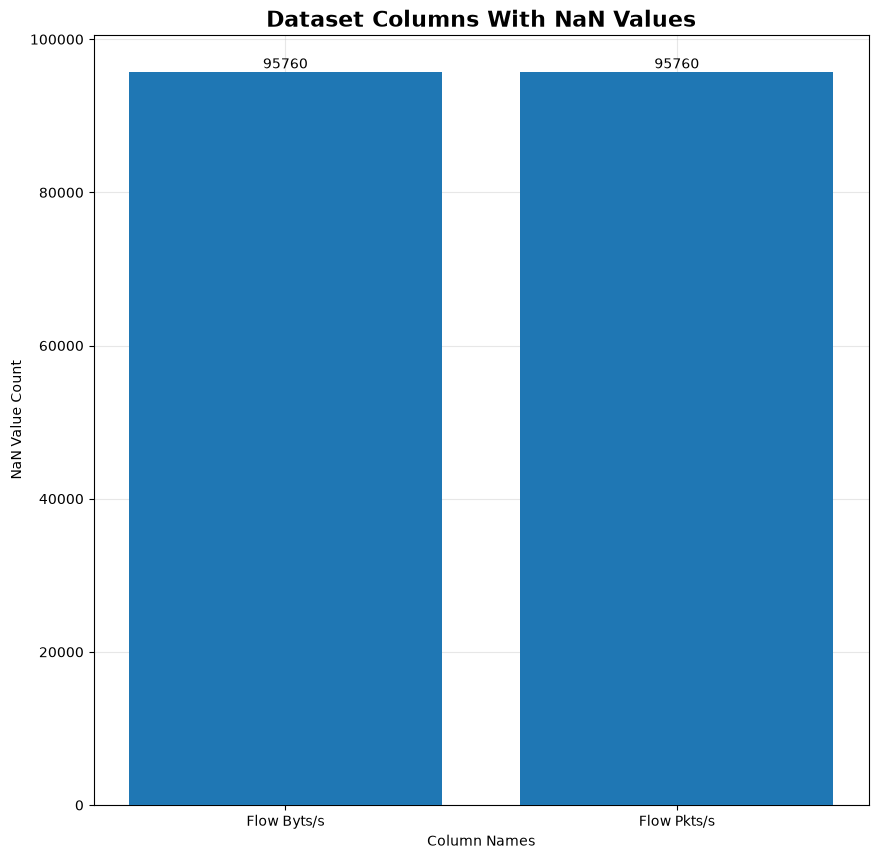

In [29]:
%%time

nan_plot(
    nan_values,
    "Dataset Columns With NaN Values",
    "Column Names",
    "NaN Value Count"
)

Delete rows that contain NaN values

In [30]:
%%time

before = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 26.2 s, sys: 21.9 ms, total: 26.2 s
Wall time: 26.3 s


In [31]:
%%time

df.dropna(inplace=True)
df = df.reset_index()

CPU times: user 3.81 s, sys: 714 ms, total: 4.52 s
Wall time: 4.56 s


In [32]:
%%time

after = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 26 s, sys: 42.2 ms, total: 26 s
Wall time: 26.1 s


In [33]:
total = 0
for (k, v), (k2, v2) in zip(before.items(), after.items()):
    print(f"{k} has {v - v2} rows dropped")
    total += v - v2
print(f"Total rows dropped: {total}")

Benign has 94459 rows dropped
DDOS attack-HOIC has 0 rows dropped
DDoS attacks-LOIC-HTTP has 0 rows dropped
DoS attacks-Hulk has 0 rows dropped
Bot has 0 rows dropped
FTP-BruteForce has 6 rows dropped
SSH-Bruteforce has 0 rows dropped
Infilteration has 1295 rows dropped
DoS attacks-SlowHTTPTest has 0 rows dropped
DoS attacks-GoldenEye has 0 rows dropped
DoS attacks-Slowloris has 0 rows dropped
DDOS attack-LOIC-UDP has 0 rows dropped
Brute Force -Web has 0 rows dropped
Brute Force -XSS has 0 rows dropped
SQL Injection has 0 rows dropped
Total rows dropped: 95760


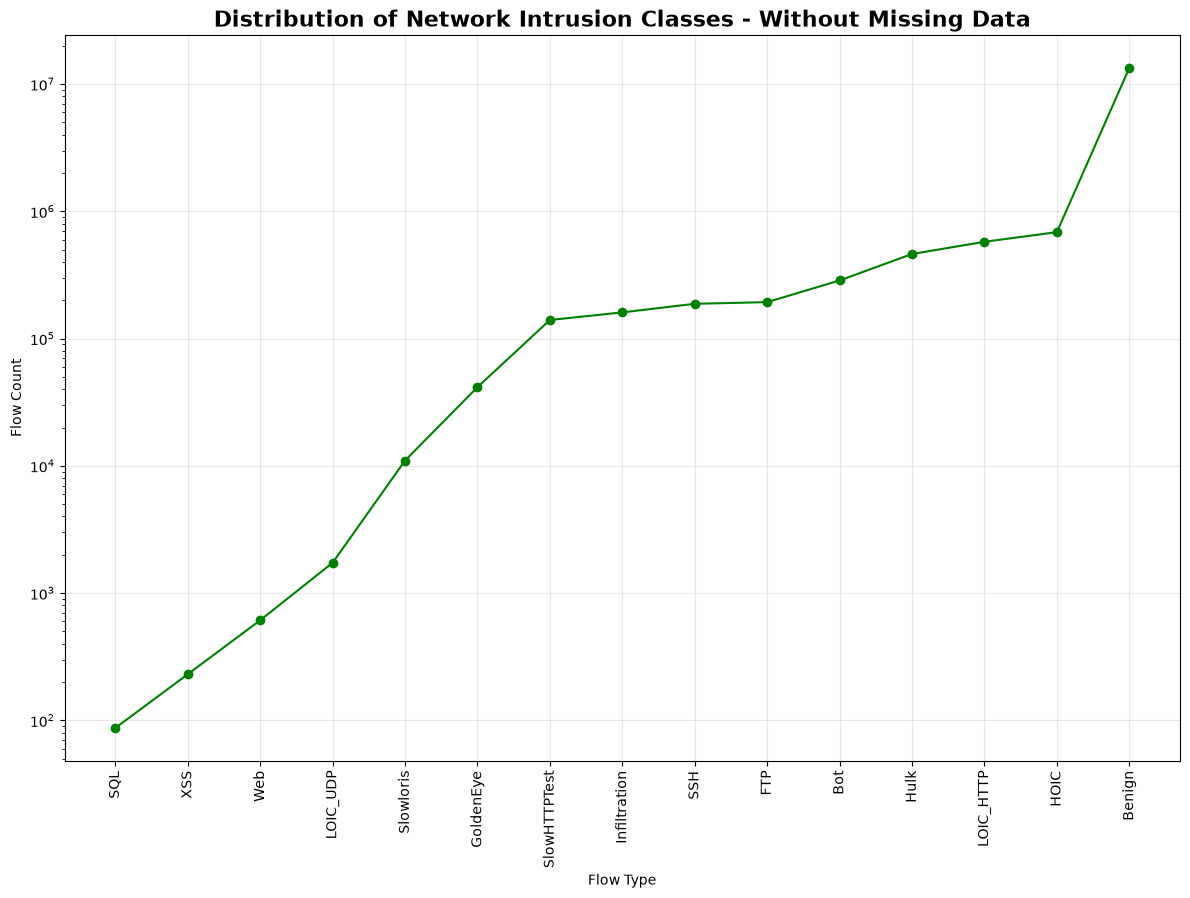

CPU times: user 2.1 s, sys: 12.4 ms, total: 2.11 s
Wall time: 2.11 s


In [34]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes - Without Missing Data",
    "Flow Type",
    "Flow Count"
)

## Drop Duplicates

In [35]:
%%time

before = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 25.9 s, sys: 18.8 ms, total: 25.9 s
Wall time: 26 s


In [36]:
%%time

df.drop_duplicates(inplace=True)
df = df.reset_index()

CPU times: user 39.5 s, sys: 2.08 s, total: 41.6 s
Wall time: 41.8 s


In [37]:
%%time

after = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 26.3 s, sys: 141 ms, total: 26.4 s
Wall time: 26.5 s


In [38]:
total = 0
for (k, v), (k2, v2) in zip(before.items(), after.items()):
    print(f"{k} has {v - v2} rows dropped")
    total += v - v2
print(f"Total rows dropped: {total}")

Benign has 0 rows dropped
DDOS attack-HOIC has 0 rows dropped
DDoS attacks-LOIC-HTTP has 0 rows dropped
DoS attacks-Hulk has 0 rows dropped
Bot has 0 rows dropped
FTP-BruteForce has 0 rows dropped
SSH-Bruteforce has 0 rows dropped
Infilteration has 0 rows dropped
DoS attacks-SlowHTTPTest has 0 rows dropped
DoS attacks-GoldenEye has 0 rows dropped
DoS attacks-Slowloris has 0 rows dropped
DDOS attack-LOIC-UDP has 0 rows dropped
Brute Force -Web has 0 rows dropped
Brute Force -XSS has 0 rows dropped
SQL Injection has 0 rows dropped
Total rows dropped: 0


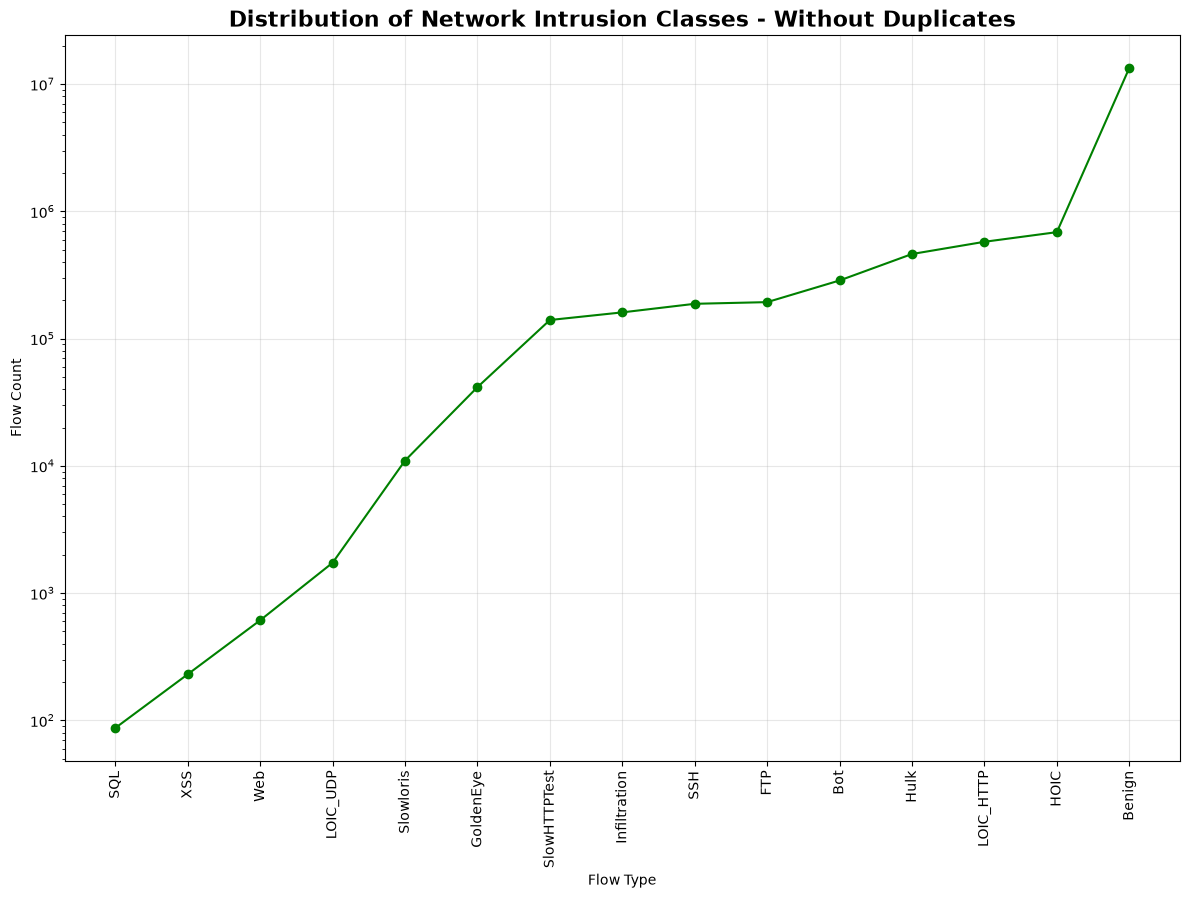

CPU times: user 2.12 s, sys: 15.8 ms, total: 2.14 s
Wall time: 2.17 s


In [39]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes - Without Duplicates",
    "Flow Type",
    "Flow Count"
)

# Feature Selection

Trim features:
1. Remove features with zero variance.
2. Remove highly correlated features.
3. Compute feature importance with XGBoost.

## Zero Variance Columns

Drop features with zero variance

In [40]:
%%time

zero_variance_cols = df.columns[df.nunique() <= 1]
print(f"Columns with zero variance: {len(zero_variance_cols)}\nColumn names: {zero_variance_cols.tolist()}\nDtype: {zero_variance_cols.dtype}")

Columns with zero variance: 8
Column names: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Dtype: str
CPU times: user 26.8 s, sys: 22.8 ms, total: 26.8 s
Wall time: 26.9 s


In [41]:
%%time

df.drop(zero_variance_cols, axis=1, inplace=True)
df.drop(['index'], axis=1, inplace=True)

CPU times: user 311 ms, sys: 182 ms, total: 493 ms
Wall time: 482 ms


In [42]:
print(f"Columns left: {len(df.columns)}")

Columns left: 72


## Calculate Correlation

Figure out and drop features that are highly correlated (|r| > 0.95) 

In [43]:
%%time

correlation_data = df.corr(method='spearman', numeric_only=True)

CPU times: user 9min 33s, sys: 49.4 s, total: 10min 22s
Wall time: 10min 25s


In [44]:
def full_correlation_heatmap(correlation_data, title, columns):
    """Plot a correlation heatmap for all available features"""
    fig, ax = plt.subplots(figsize=(16, 14))

    im = ax.imshow(
        correlation_data,
        vmin=-1,
        vmax=1,
        aspect="equal"
    )

    # Feature names
    ax.set_xticks(np.arange(len(columns)))
    ax.set_yticks(np.arange(len(columns)))

    ax.set_xticklabels(
        columns,
        rotation=90,
        fontsize=8
    )
    ax.set_yticklabels(
        columns,
        fontsize=8
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(
        f"Spearman Correlation (ρ)",
        fontsize=12
    )

    ax.set_title(
        f"{title}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

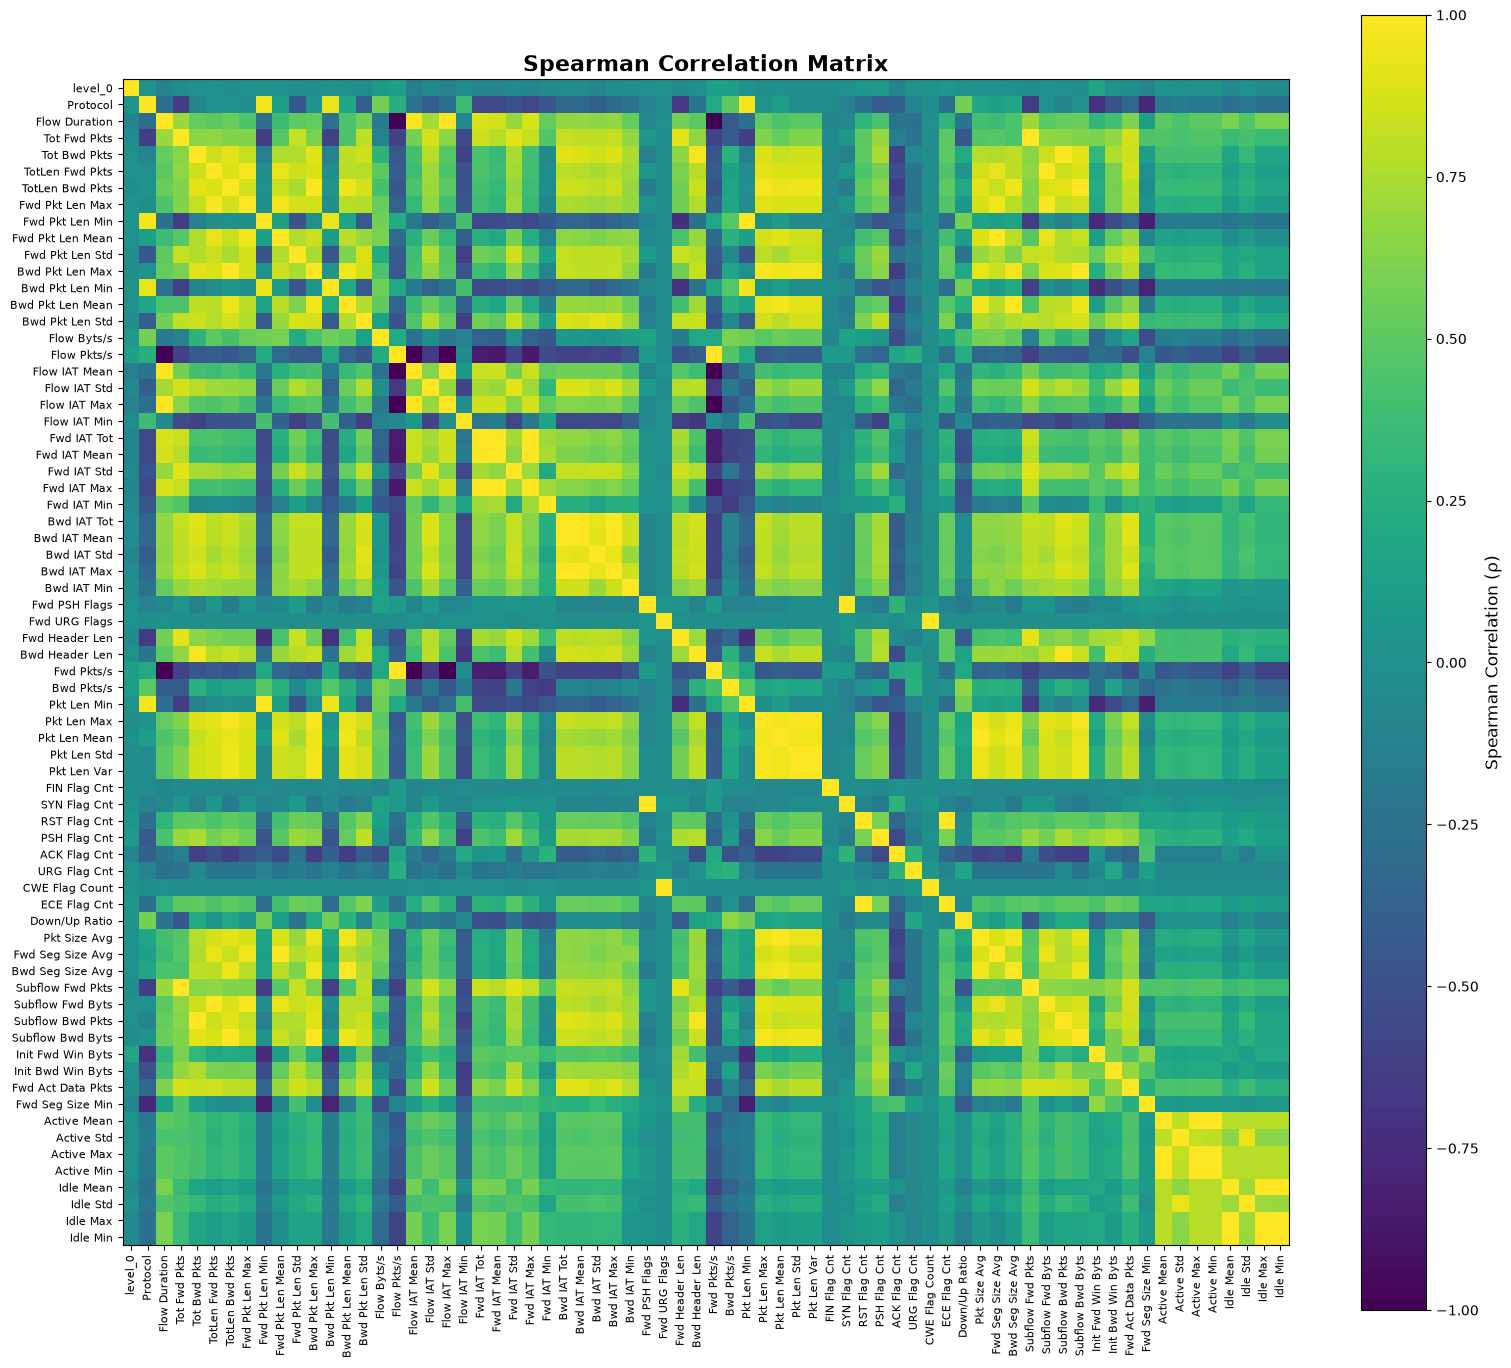

CPU times: user 1.25 s, sys: 453 ms, total: 1.7 s
Wall time: 1.95 s


In [45]:
%%time

correlation_columns = correlation_data.columns
full_correlation_heatmap(correlation_data, "Spearman Correlation Matrix", correlation_columns)

In [46]:
correlation_data

,level_0,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
level_0,1.000000,0.019111,-0.101270,-0.026230,0.001153,0.014231,-0.010139,0.008313,0.021678,0.008966,...,-0.004554,-0.093164,0.019121,0.006326,0.018814,0.019402,-0.040409,0.011048,-0.039946,-0.040845
Protocol,0.019111,1.000000,-0.294071,-0.634359,-0.093012,0.000626,0.030138,-0.000210,0.959886,0.132430,...,-0.323145,-0.768434,-0.193439,-0.162587,-0.193473,-0.193466,-0.270615,-0.215990,-0.270487,-0.270435
Flow Duration,-0.101270,-0.294071,1.000000,0.696148,0.524543,0.498531,0.542821,0.451119,-0.273092,0.369602,...,0.611373,0.137847,0.495123,0.429765,0.495897,0.494297,0.600321,0.460149,0.600420,0.599861
Tot Fwd Pkts,-0.026230,-0.634359,0.696148,1.000000,0.647961,0.665453,0.617276,0.617386,-0.633215,0.482075,...,0.874109,0.450957,0.458903,0.425727,0.460751,0.456976,0.366660,0.417399,0.366994,0.365719
Tot Bwd Pkts,0.001153,-0.093012,0.524543,0.647961,1.000000,0.850970,0.916041,0.814333,-0.127276,0.763133,...,0.845980,0.110936,0.412559,0.401222,0.414699,0.410437,0.187004,0.341786,0.187279,0.187199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,0.019402,-0.193466,0.494297,0.456976,0.410437,0.309866,0.354409,0.265987,-0.180114,0.152204,...,0.440772,0.093592,0.999088,0.798058,0.997955,1.000000,0.787975,0.774805,0.789010,0.786555
Idle Mean,-0.040409,-0.270615,0.600321,0.366660,0.187004,0.121878,0.165573,0.088049,-0.224528,-0.007640,...,0.269467,0.077667,0.787907,0.650880,0.787307,0.787975,1.000000,0.703321,0.999789,0.999702
Idle Std,0.011048,-0.215990,0.460149,0.417399,0.341786,0.236749,0.285815,0.194846,-0.160693,0.085617,...,0.381966,0.012284,0.784582,0.933501,0.793763,0.774805,0.703321,1.000000,0.706416,0.697822
Idle Max,-0.039946,-0.270487,0.600420,0.366994,0.187279,0.122235,0.165754,0.088169,-0.224324,-0.007391,...,0.269649,0.077688,0.789077,0.653099,0.788531,0.789010,0.999789,0.706416,1.000000,0.999263


Create a numpy array that keeps only the highly correlated features of the upper triangle
Everything else is set to `nan`

In [47]:
%%time

threshold = 0.95

numpy_matrix = correlation_data.to_numpy().copy()
numpy_matrix[np.abs(numpy_matrix) < threshold] = np.nan # Keep only strong correlations
numpy_matrix[np.tril_indices_from(numpy_matrix, k=-1)] = np.nan

CPU times: user 1.13 ms, sys: 932 μs, total: 2.06 ms
Wall time: 1.32 ms


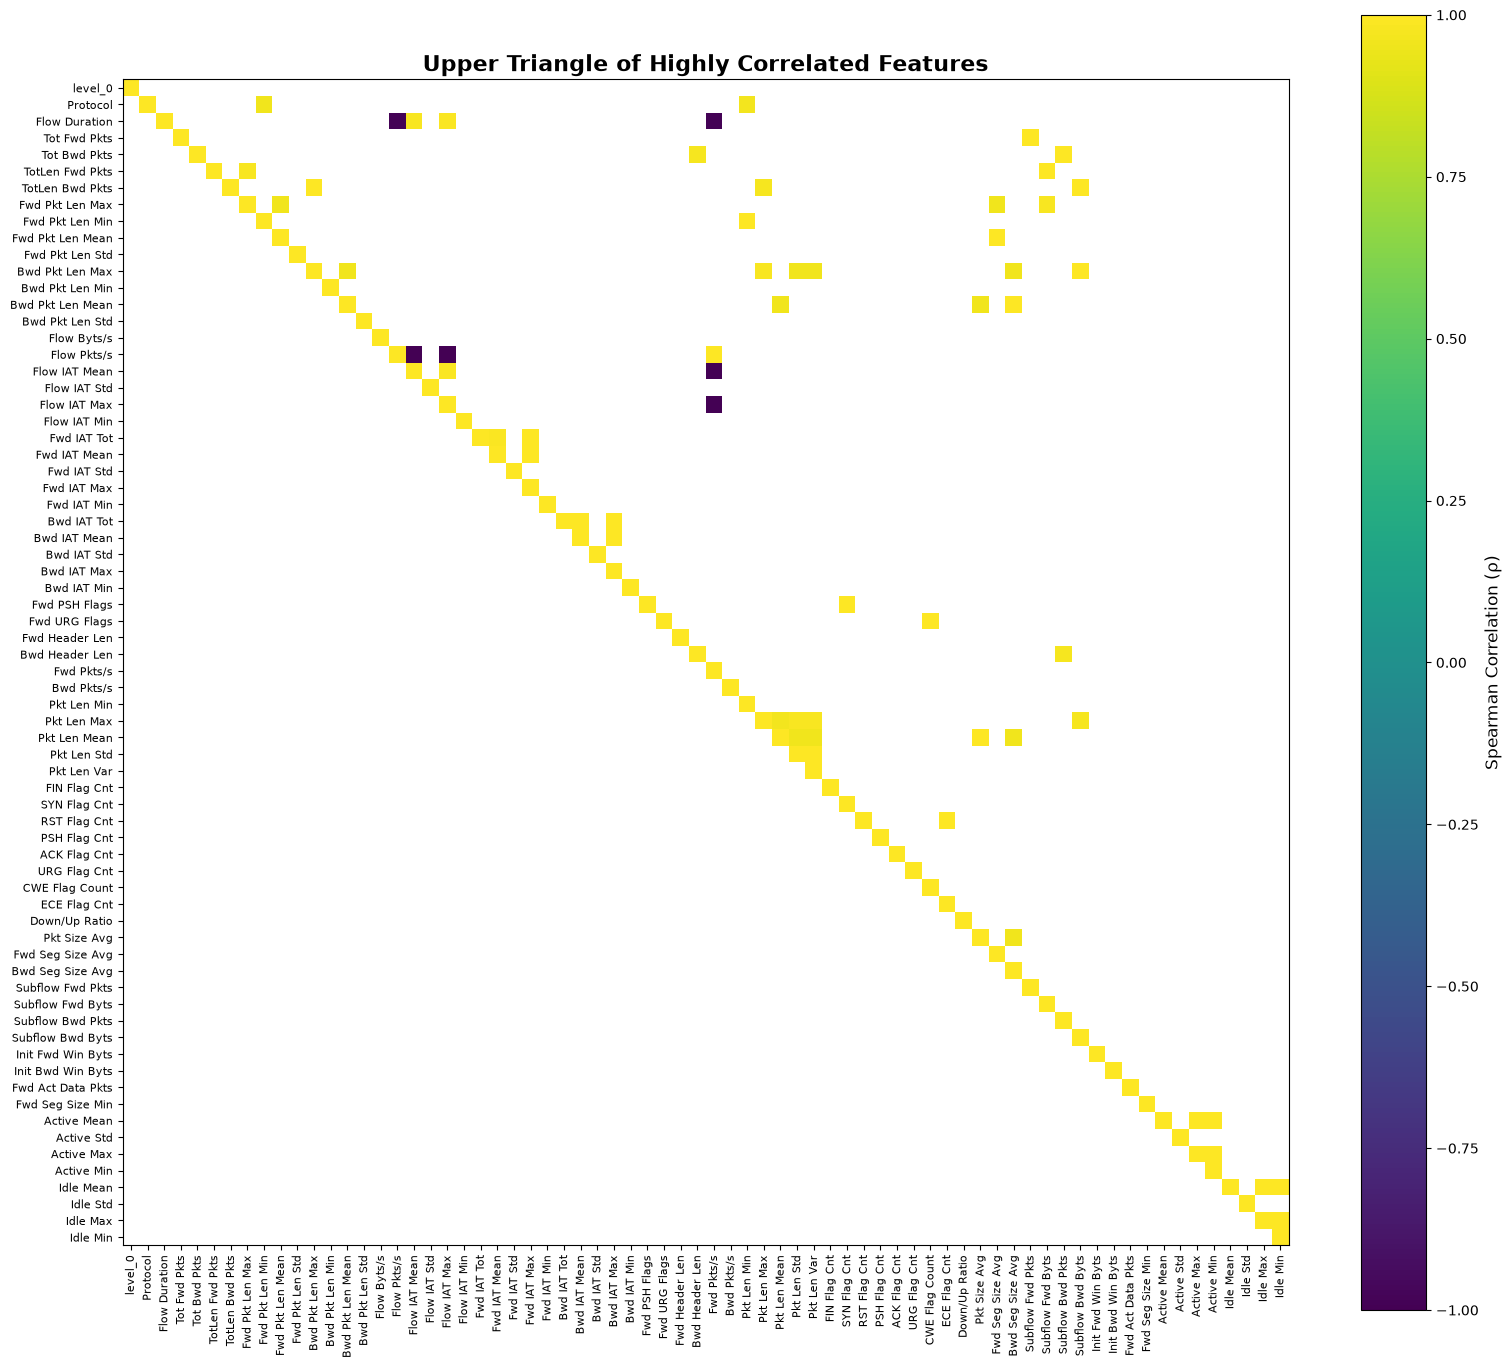

CPU times: user 1.12 s, sys: 52.7 ms, total: 1.18 s
Wall time: 1.19 s


In [48]:
%%time

full_correlation_heatmap(numpy_matrix, "Upper Triangle of Highly Correlated Features", correlation_columns)

Print correlated features

In [49]:
def correlatedColumns(correlation_data):
    """Print correlated columns and their correlation coefficients"""
    rows, cols = np.where(np.triu(correlation_data.to_numpy() > threshold, k=1))

    for r, c in zip(rows, cols):
        row_name = correlation_data.index[r]
        column_name = correlation_data.columns[c]
        print(f"{row_name} <-> {column_name} ({correlation_data[row_name][column_name]})")

In [50]:
%%time

correlatedColumns(correlation_data)

Protocol <-> Fwd Pkt Len Min (0.9598859192147993)
Protocol <-> Pkt Len Min (0.9636984460247796)
Flow Duration <-> Flow IAT Mean (0.9797559877340853)
Flow Duration <-> Flow IAT Max (0.992164015596482)
Tot Fwd Pkts <-> Subflow Fwd Pkts (1.0)
Tot Bwd Pkts <-> Bwd Header Len (0.9729448951891976)
Tot Bwd Pkts <-> Subflow Bwd Pkts (1.0)
TotLen Fwd Pkts <-> Fwd Pkt Len Max (0.9770520925933648)
TotLen Fwd Pkts <-> Subflow Fwd Byts (1.0)
TotLen Bwd Pkts <-> Bwd Pkt Len Max (0.9929387917400325)
TotLen Bwd Pkts <-> Pkt Len Max (0.9746036669577159)
TotLen Bwd Pkts <-> Subflow Bwd Byts (1.0000000000000009)
Fwd Pkt Len Max <-> Fwd Pkt Len Mean (0.9569503453080206)
Fwd Pkt Len Max <-> Fwd Seg Size Avg (0.956949947630783)
Fwd Pkt Len Max <-> Subflow Fwd Byts (0.9770520925933648)
Fwd Pkt Len Min <-> Pkt Len Min (0.996149515087488)
Fwd Pkt Len Mean <-> Fwd Seg Size Avg (0.9999995225237432)
Bwd Pkt Len Max <-> Bwd Pkt Len Mean (0.95658046435315)
Bwd Pkt Len Max <-> Pkt Len Max (0.9815854830747707)
Bwd Pk

In [51]:
correlated_features_to_drop = [
    'Flow IAT Mean',
    'Flow IAT Max',
    'Fwd IAT Tot',
    'Fwd IAT Max',
    'Bwd IAT Tot',
    'Bwd IAT Max',
    'Active Max',
    'Active Min',
    'Idle Max',
    'Idle Min',
    'Subflow Fwd Pkts',
    'Subflow Bwd Pkts',
    'Bwd Header Len',
    'Fwd Pkts/s',
    'Bwd Pkt Len Max',
    'Bwd Pkt Len Mean',
    'Pkt Len Max',
    'Pkt Len Mean',
    'Pkt Len Var',
    'Pkt Size Avg',
    'Bwd Seg Size Avg',
    'Subflow Bwd Byts',
    'Fwd Pkt Len Max',
    'Fwd Seg Size Avg',
    'Subflow Fwd Byts',
    'Fwd Pkt Len Min',
    'ECE Flag Cnt',
    'Fwd PSH Flags',
    'CWE Flag Count'
]

In [52]:
print(f"Features before dropping correlated features: {len(df.columns)}")

Features before dropping correlated features: 72


In [53]:
df.drop(correlated_features_to_drop, axis=1, inplace=True)

In [54]:
print(f"Features after dropping correlated features: {len(df.columns)}")

Features after dropping correlated features: 43


## Feature Importance

Use XGBoost on a stratified dataset subsample to figure out which features have a highest influence on classification decisions

As a baseline benchmark of feature importance, add 10 columns with random data 

In [55]:
rng = np.random.default_rng(42)

for i in range(10):
    df[f"random_probe_{i}"] = rng.random(len(df))

In [56]:
labels = df['Label']

In [57]:
features = df.drop(['Label', 'Label_Short'], axis=1)

In [58]:
labels

0                  Benign
1                  Benign
2                  Benign
3                  Benign
4                  Benign
                ...      
16137178    Infilteration
16137179    Infilteration
16137180           Benign
16137181    Infilteration
16137182    Infilteration
Name: Label, Length: 16137183, dtype: str

In [59]:
features.head()

,level_0,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Min,...,random_probe_0,random_probe_1,random_probe_2,random_probe_3,random_probe_4,random_probe_5,random_probe_6,random_probe_7,random_probe_8,random_probe_9
0,0,6,141385,9,7,553.0,3773.0,61.444444,87.534438,0.0,...,0.773956,0.947729,0.300230,0.462317,0.449271,0.759851,0.088978,0.912468,0.062292,0.959654
1,1,6,281,2,1,38.0,0.0,19.000000,26.870058,0.0,...,0.438878,0.222104,0.699372,0.241615,0.080159,0.551115,0.410667,0.693712,0.874355,0.485019
2,2,6,279824,11,15,1086.0,10527.0,98.727273,129.392497,0.0,...,0.858598,0.428000,0.568442,0.200601,0.787698,0.540850,0.012559,0.858648,0.050375,0.432543
3,3,6,132,2,0,0.0,0.0,0.000000,0.000000,0.0,...,0.697368,0.469976,0.446693,0.098378,0.941569,0.675455,0.216329,0.134972,0.249671,0.174655
4,4,6,274016,9,13,1285.0,6141.0,142.777778,183.887722,0.0,...,0.094177,0.104618,0.394784,0.116049,0.064245,0.206955,0.938476,0.691024,0.023495,0.966171


In [60]:
%%time

le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

CPU times: user 2.06 s, sys: 607 ms, total: 2.66 s
Wall time: 2.68 s


In [61]:
encoded_labels

array([ 0,  0,  0, ...,  0, 12, 12], shape=(16137183,))

In [62]:
params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',

    'n_estimators': 300,          # more trees, but shallow — see max_depth
    'max_depth': 4,               # shallower than default 6

    'learning_rate': 0.05,        # lower LR + more trees = smoother gain attribution

    'subsample': 0.8,             # row subsampling — reduces overfit-driven gain
    'colsample_bytree': 0.8,      # column subsampling — this is the key one for correlated features
    'colsample_bylevel': 0.8,     # extra decorrelation at each tree level

    'min_child_weight': 5,        # avoid tiny leaves capturing spurious high-gain splits
    'reg_alpha': 0.1,             # L1 — encourages sparsity, useful for feature selection
    'reg_lambda': 1.5,            # L2 — dampens any single feature dominating gain

    'tree_method': 'hist',        # faster, fine for this row count
}

Retrain XGBoost classifier with 5 different seeds for train/test data split and XGBoost randomness

Data collected:
1. For each feature, collect feature importance metrics:
    * Gain
    * Weight
    * Cover
    * Relative Importance
    * Rank
2. For each metric, collect values and compute:
    * Standard Deviation
    * Mean
    * Coefficient of Variance

Results are written to JSON file

In [63]:
def serializeNumpy(obj):
    """Serialize Numpy value of any type to JSON"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

In [64]:
%%time

iter_counter = 1
seeds = [42, 21, 77, 123, 256, 678, 999, 134135, 81935, 635909]
iterations = len(seeds)
IMPORTANCE_TYPES = ["gain", "weight", "cover"]
feature_importance_stats = {}

for columns in features.columns:
    feature_importance_stats[columns] = {
        "gain": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "weight": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "cover": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "importance": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "rank": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        }
    }

for seed in seeds:
    start = time.time()
    _, X_subsample, _, y_subsample = train_test_split(
        features, encoded_labels,
        test_size=0.1,
        stratify=labels,
        random_state=seed
    )

    rank = len(features.columns)
    params['random_state'] = seed
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_subsample, y_subsample)

    importances_dict = {}
    importances_dict_sorted = {}
    for name, importance in zip(model.feature_names_in_, model.feature_importances_):
        importances_dict[name] = importance

    importances_dict_sorted = {k: v for k, v in sorted(importances_dict.items(), key=lambda item: item[1])}

    for key, value in importances_dict_sorted.items():
        feature_importance_stats[key]["importance"]["data"].append(value)
        feature_importance_stats[key]["rank"]["data"].append(rank)
        rank -= 1

    booster = model.get_booster()
    for itype in IMPORTANCE_TYPES:
        for key, value in booster.get_score(importance_type=itype).items():
            feature_importance_stats[key][itype]["data"].append(value)

    for column in feature_importance_stats:
        for key in feature_importance_stats[column]:
            data = feature_importance_stats[column][key]["data"]
            std = np.std(data)
            feature_importance_stats[column][key]["std"] = std
            mean = np.mean(data)
            feature_importance_stats[column][key]["mean"] = mean
            cv = (std / mean) * 100
            feature_importance_stats[column][key]["cv"] = cv

    end = time.time()
    print(f"Iteration {iter_counter}/{iterations} finished in {end - start} seconds")
    iter_counter += 1

# Write statistics to a JSON file
with open("data.json", "w") as f:
    f.write(json.dumps(feature_importance_stats, default=serializeNumpy, indent=4))

Iteration 1/10 finished in 414.09267592430115 seconds
Iteration 2/10 finished in 379.02949261665344 seconds
Iteration 3/10 finished in 382.7559440135956 seconds
Iteration 4/10 finished in 381.9146227836609 seconds
Iteration 5/10 finished in 390.14232444763184 seconds
Iteration 6/10 finished in 392.73280334472656 seconds
Iteration 7/10 finished in 466.77319622039795 seconds
Iteration 8/10 finished in 409.6838629245758 seconds
Iteration 9/10 finished in 397.6674220561981 seconds
Iteration 10/10 finished in 409.3741772174835 seconds
CPU times: user 8h 13min 19s, sys: 42.6 s, total: 8h 14min 1s
Wall time: 1h 7min 4s


# Plotting Feature Statistics

For every statistical feature, plot the following:
1. Log plot:
    * Coefficient of Variance (CV)
    * Mean
2. Scatterplot (CV + Mean)

In [65]:
gain_mean, gain_cv, weight_mean, weight_cv, cover_mean, cover_cv, importance_mean, importance_cv, rank_mean, rank_cv = [{} for x in range(10)]

In [66]:
for column in feature_importance_stats.keys():
    for metric in feature_importance_stats[column].keys():
        mean = feature_importance_stats[column][metric]["mean"]
        cv = feature_importance_stats[column][metric]["cv"]
        if metric == "gain":
            gain_mean[column] = mean
            gain_cv[column] = cv
        elif metric == "weight":
            weight_mean[column] = mean
            weight_cv[column] = cv
        elif metric == "cover":
            cover_mean[column] = mean
            cover_cv[column] = cv
        elif metric == "importance":
            importance_mean[column] = mean
            importance_cv[column] = cv
        elif metric == "rank":
            rank_mean[column] = mean
            rank_cv[column] = cv

In [67]:
gain_mean_sorted = {k: v for k, v in sorted(gain_mean.items(), key=lambda item: item[1])}
gain_cv_sorted = {k: v for k, v in sorted(gain_cv.items(), key=lambda item: item[1])}
weight_mean_sorted = {k: v for k, v in sorted(weight_mean.items(), key=lambda item: item[1])}
weight_cv_sorted = {k: v for k, v in sorted(weight_cv.items(), key=lambda item: item[1])}
cover_mean_sorted = {k: v for k, v in sorted(cover_mean.items(), key=lambda item: item[1])}
cover_cv_sorted = {k: v for k, v in sorted(cover_cv.items(), key=lambda item: item[1])}
importance_mean_sorted = {k: v for k, v in sorted(importance_mean.items(), key=lambda item: item[1])}
importance_cv_sorted = {k: v for k, v in sorted(importance_cv.items(), key=lambda item: item[1])}
rank_mean_sorted = {k: v for k, v in sorted(rank_mean.items(), key=lambda item: item[1])}
rank_cv_sorted = {k: v for k, v in sorted(rank_cv.items(), key=lambda item: item[1])}

In [68]:
random_columns = [f"random_probe_{x}" for x in range(10)]

gain_mean_random = np.max([gain_mean_sorted[x] for x in random_columns])
gain_cv_random = np.max([gain_cv_sorted[x] for x in random_columns])
weight_mean_random = np.max([weight_mean_sorted[x] for x in random_columns])
weight_cv_random = np.max([weight_cv_sorted[x] for x in random_columns])
cover_mean_random = np.max([cover_mean_sorted[x] for x in random_columns])
cover_cv_random = np.max([cover_cv_sorted[x] for x in random_columns])
importance_mean_random = np.max([importance_mean_sorted[x] for x in random_columns])
importance_cv_random = np.max([importance_cv_sorted[x] for x in random_columns])
rank_mean_random = np.max([rank_mean_sorted[x] for x in random_columns])
rank_cv_random = np.max([rank_cv_sorted[x] for x in random_columns])

In [69]:
def feature_importance(plot_data, title, xlabel, ylabel, threshold):
    """Coefficient of variance for XGBoost-ranked variables"""
    x, y = [[] for z in range(2)]
    length = len(plot_data.items()) - 1
    for key, value in plot_data.items():
        x.append(key)
        y.append(value)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")  # Convert y-axis to logarithmic scale
    ax.plot(x, y, "o-", color="green")
    if threshold > 0:
        ax.plot([0, length], [threshold, threshold], "k--")
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.tight_layout()
    plt.xticks(rotation=90)
    plt.title(f"{title}", fontsize = 16, fontweight="bold")
    plt.show()
    fig.savefig(f"images/{title}.png", bbox_inches="tight")
    fig.clear()
    plt.close(fig)

## Mean and CV Plots

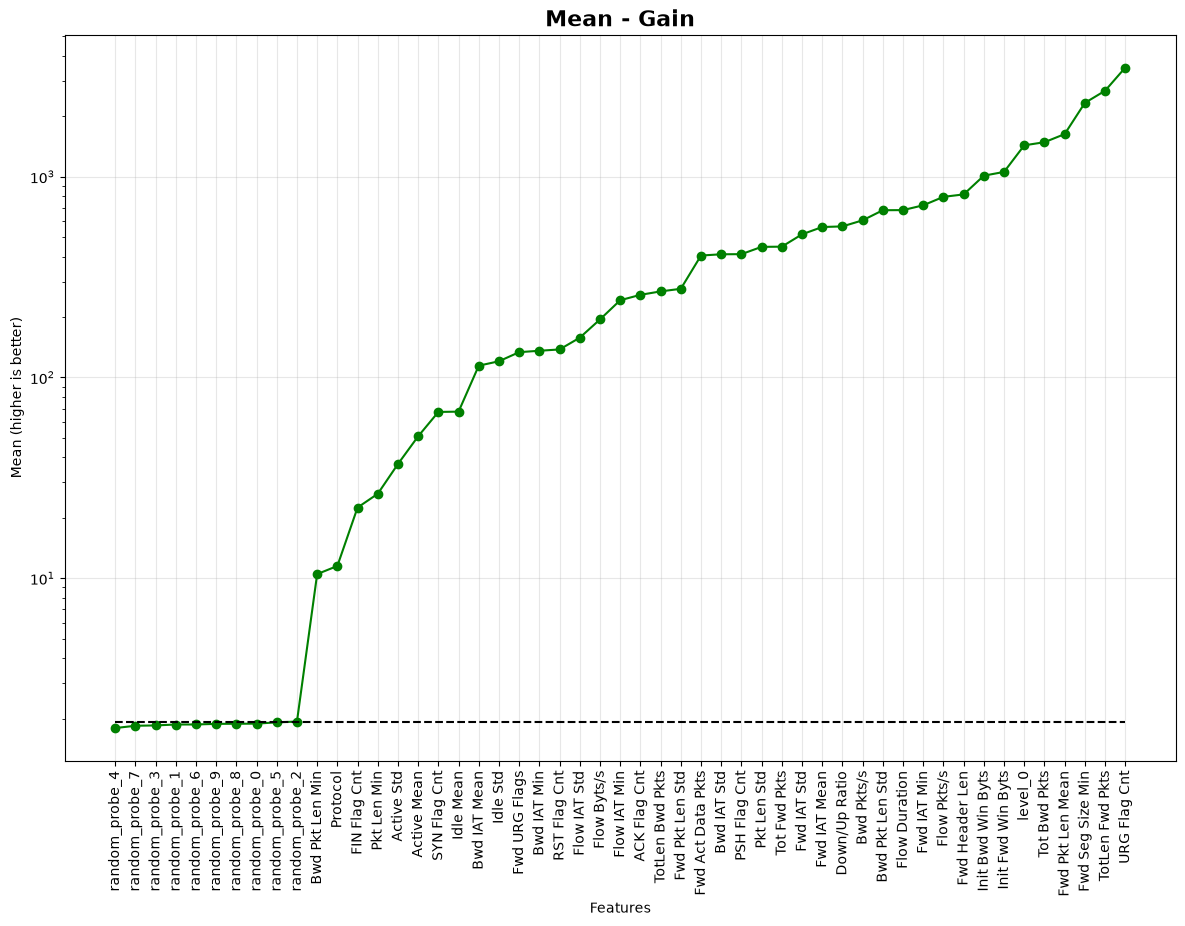

In [70]:
feature_importance(
    gain_mean_sorted,
    "Mean - Gain",
    "Features",
    "Mean (higher is better)",
    gain_mean_random
)

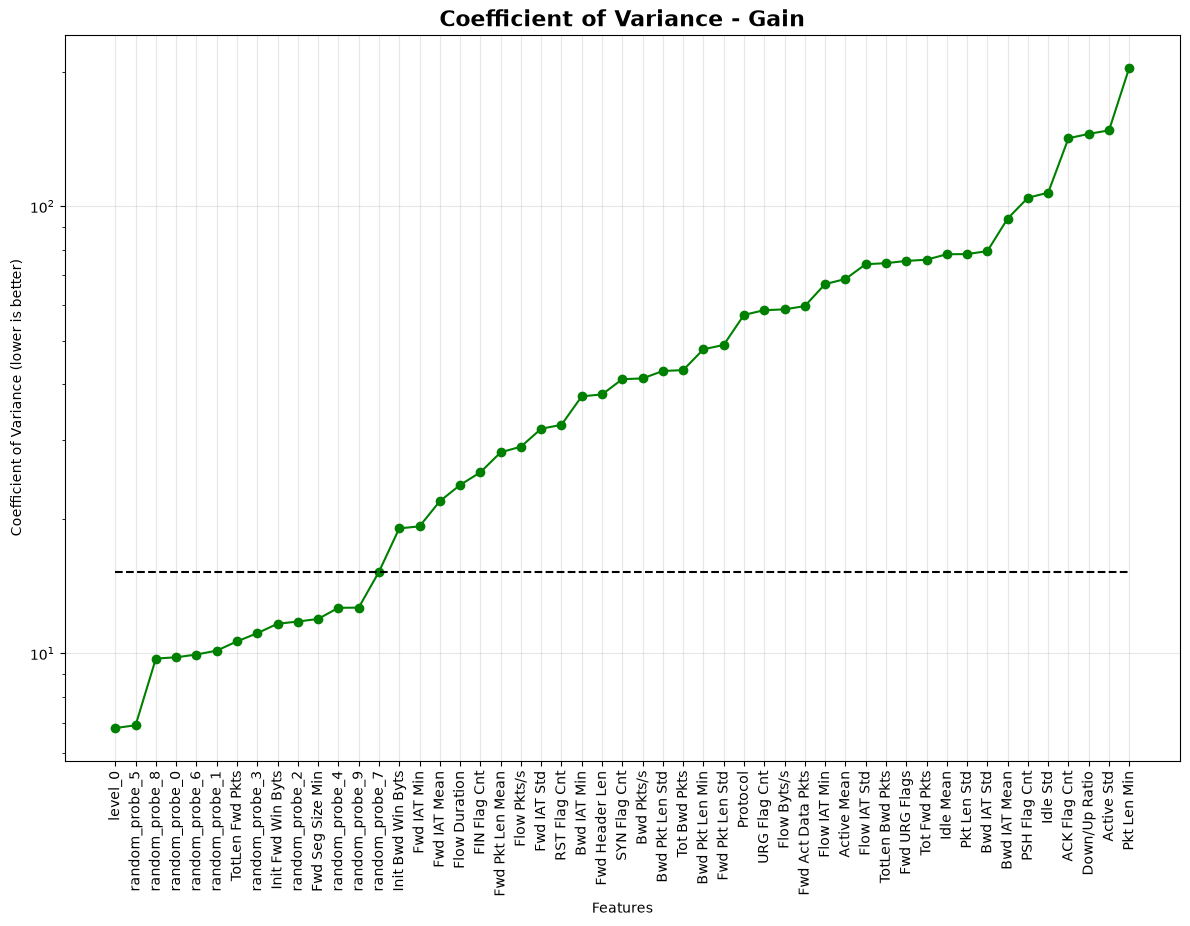

In [71]:
feature_importance(
    gain_cv_sorted,
    "Coefficient of Variance - Gain",
    "Features",
    "Coefficient of Variance (lower is better)",
    gain_cv_random
)

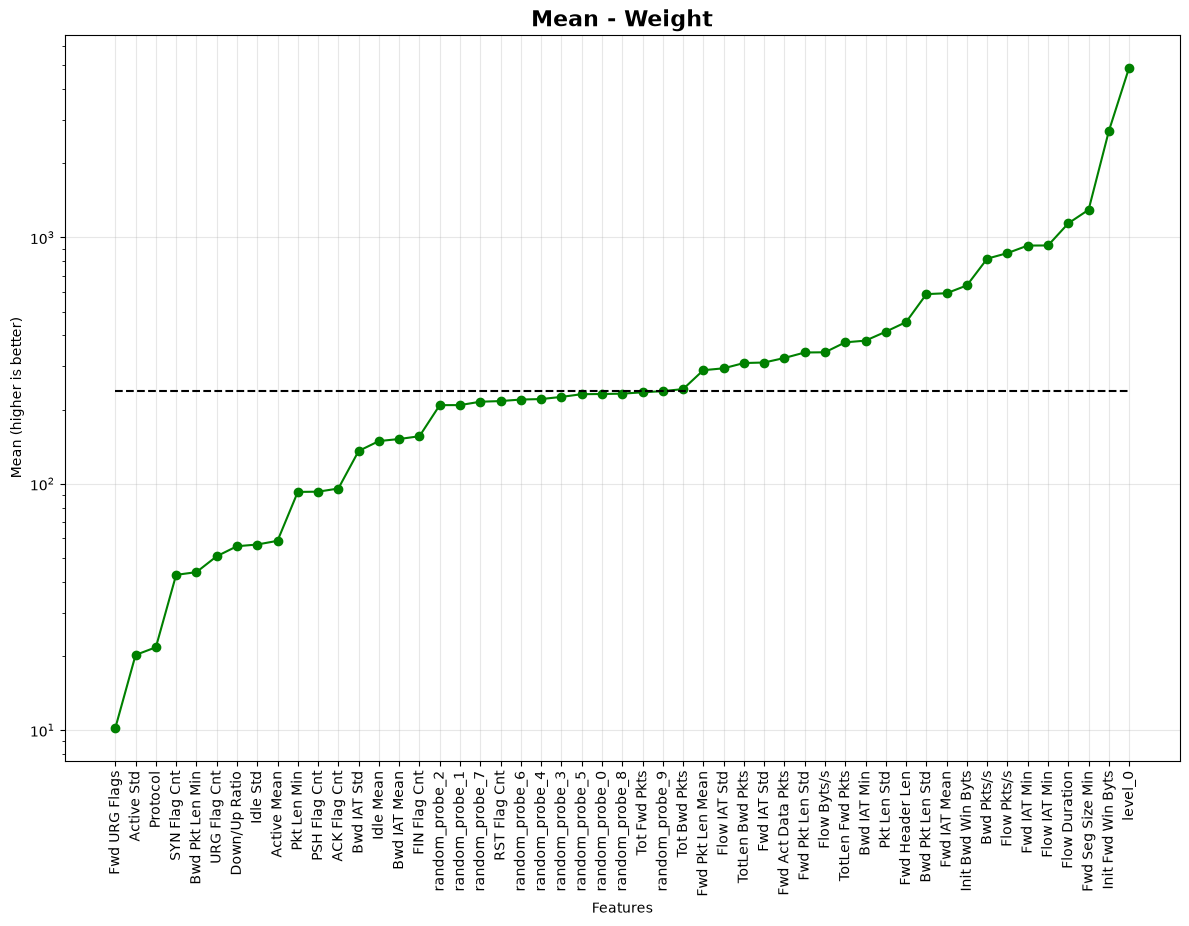

In [72]:
feature_importance(
    weight_mean_sorted,
    "Mean - Weight",
    "Features",
    "Mean (higher is better)",
    weight_mean_random
)

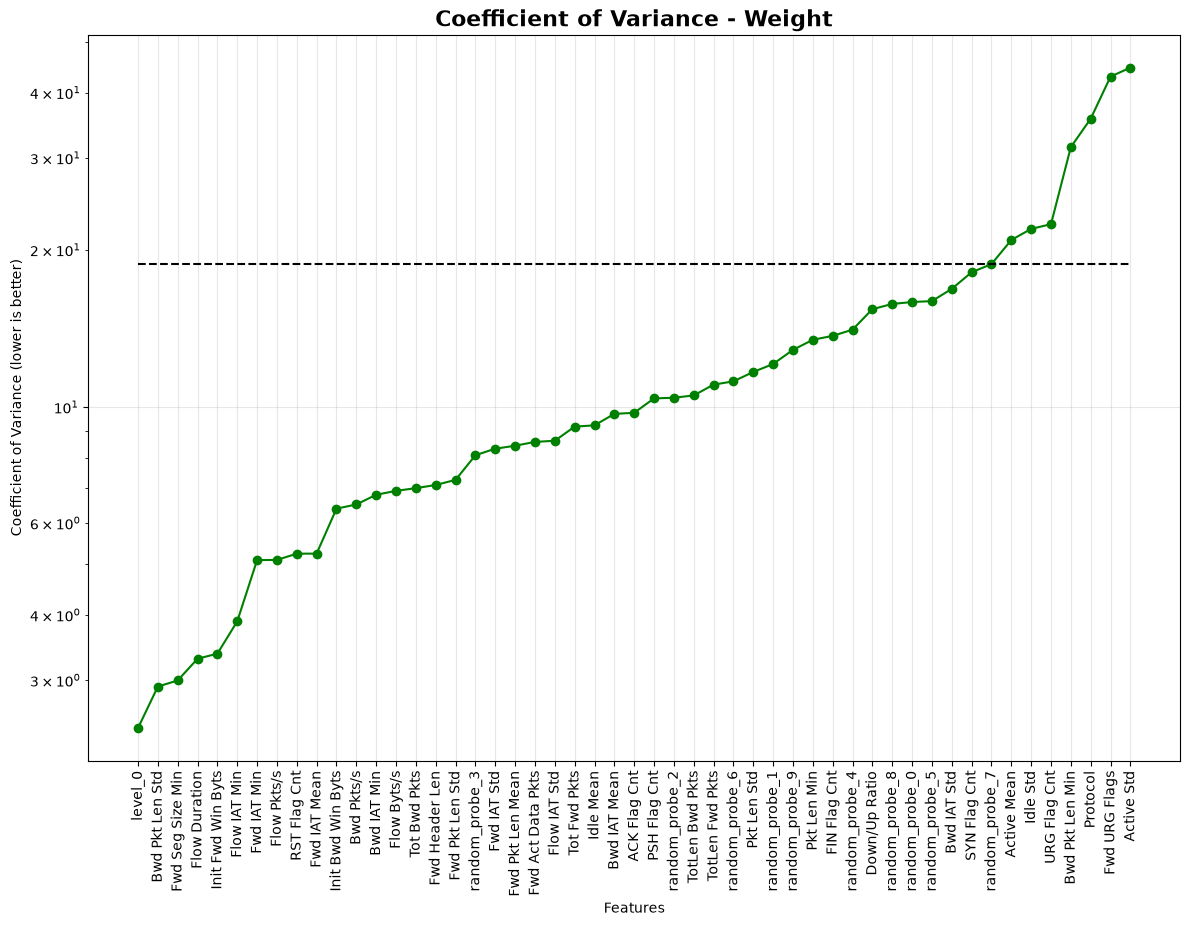

In [73]:
feature_importance(
    weight_cv_sorted,
    "Coefficient of Variance - Weight",
    "Features",
    "Coefficient of Variance (lower is better)",
    weight_cv_random
)

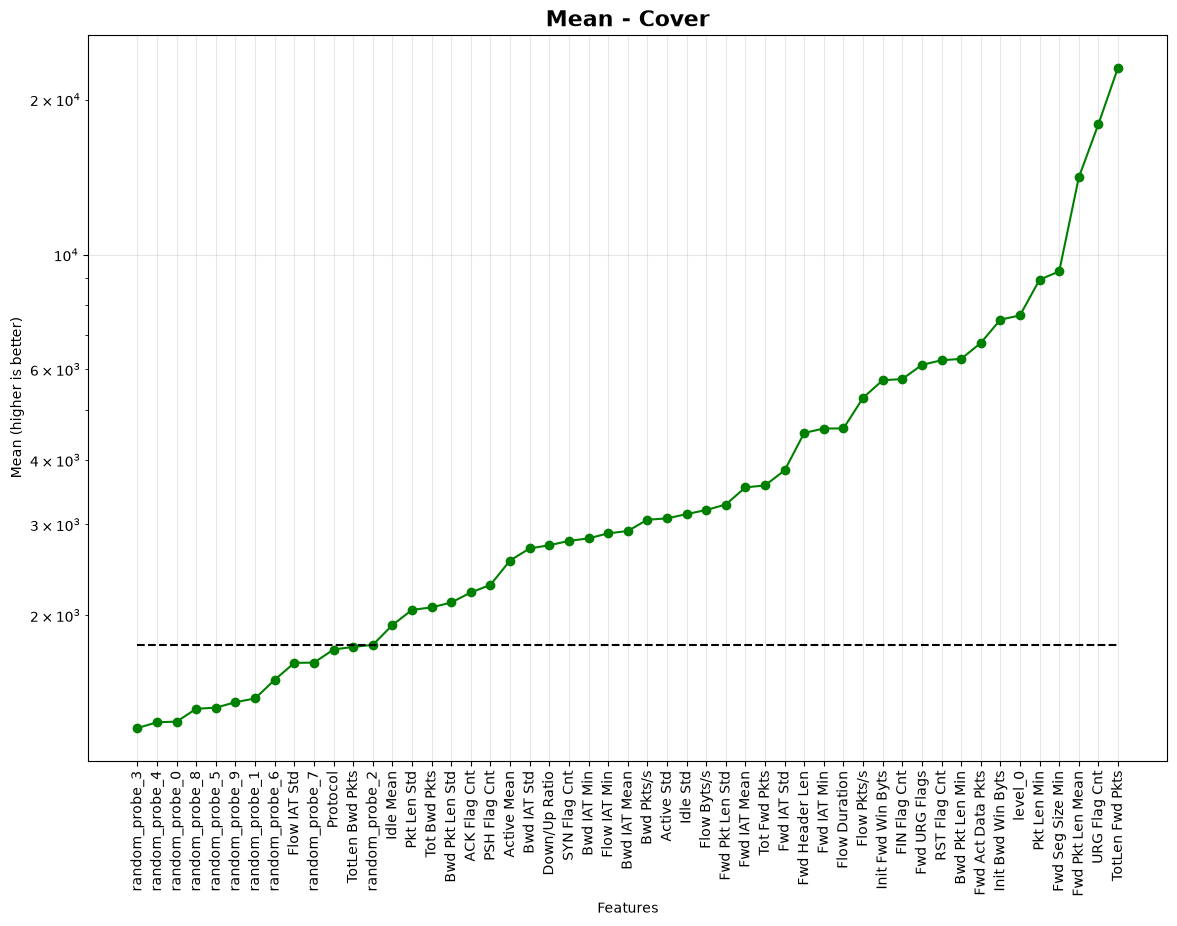

In [74]:
feature_importance(
    cover_mean_sorted,
    "Mean - Cover",
    "Features",
    "Mean (higher is better)",
    cover_mean_random
)

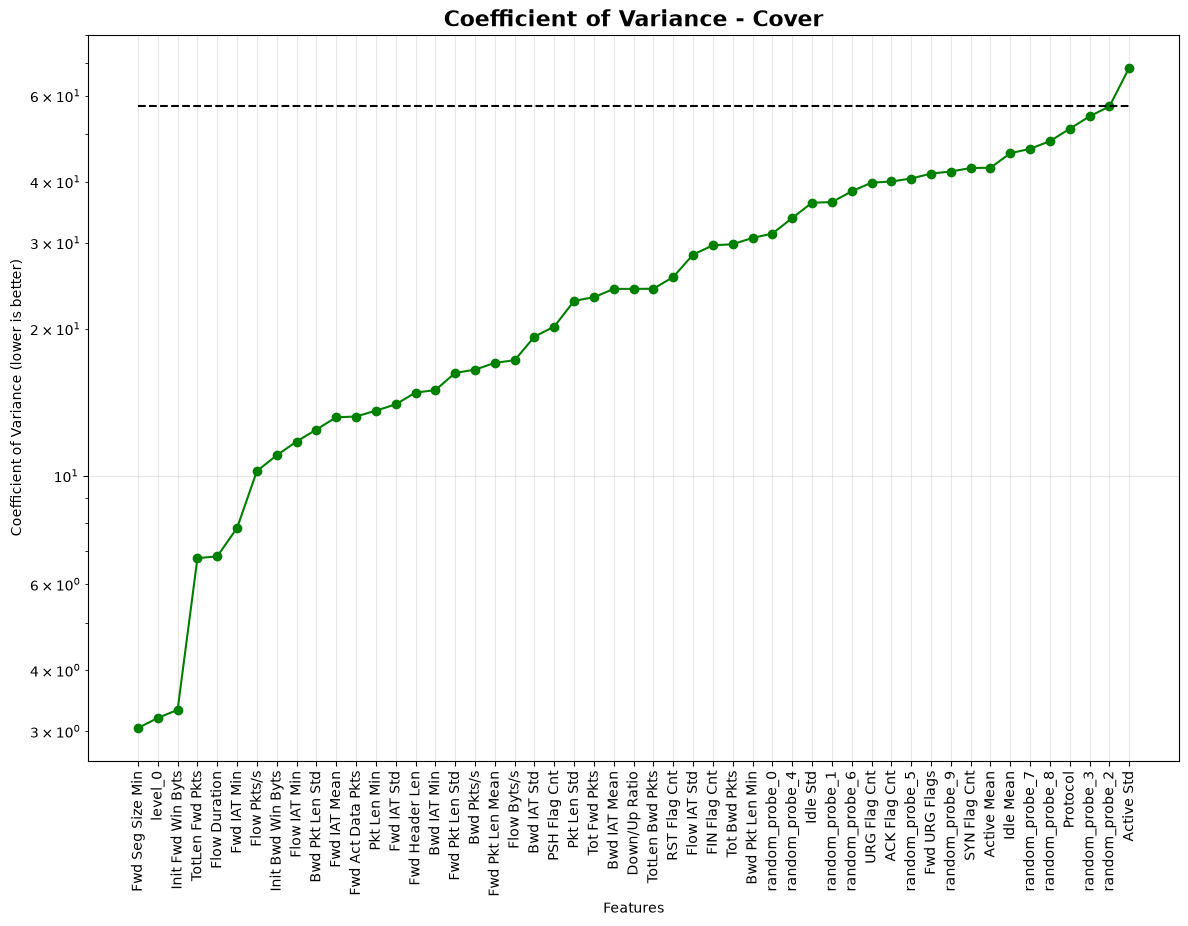

In [75]:
feature_importance(
    cover_cv_sorted,
    "Coefficient of Variance - Cover",
    "Features",
    "Coefficient of Variance (lower is better)",
    cover_cv_random
)

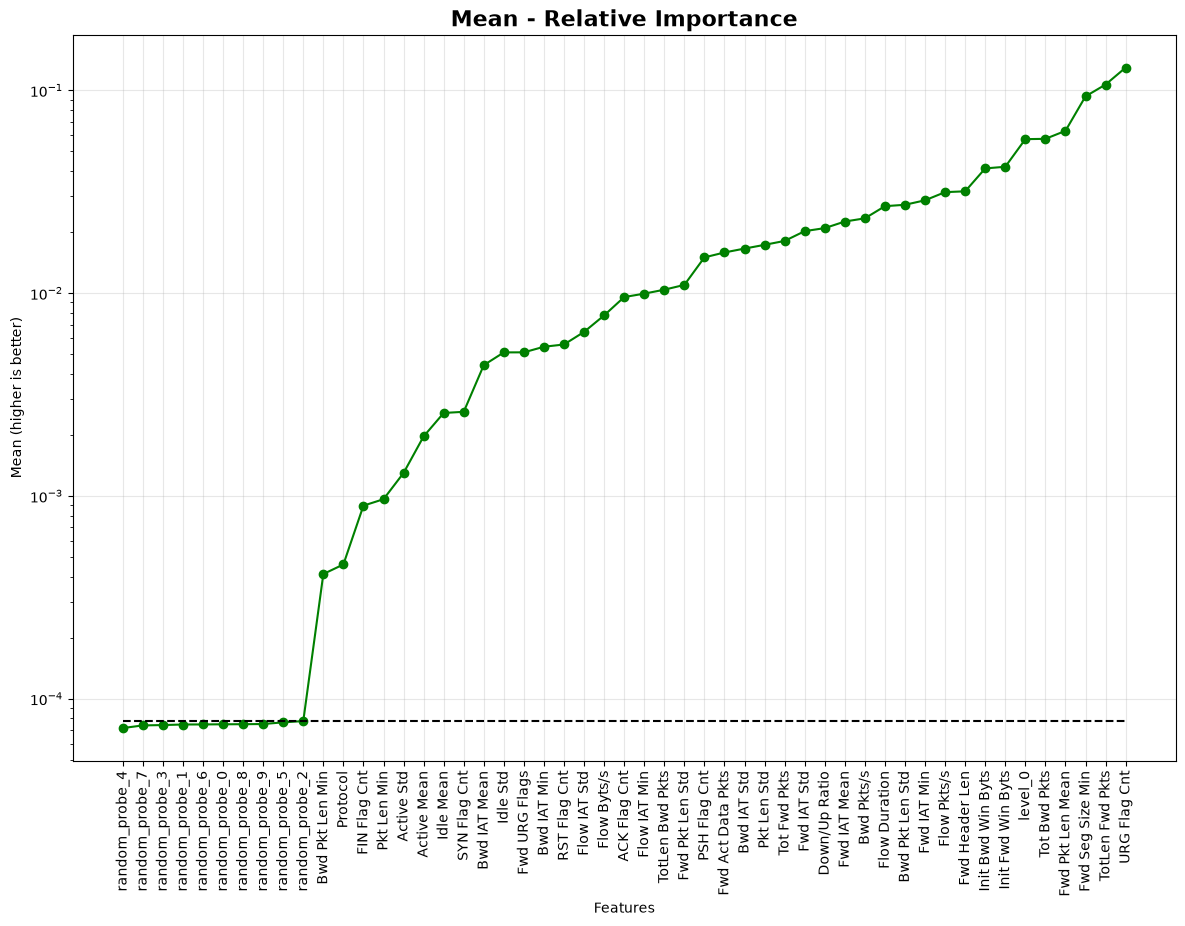

In [76]:
feature_importance(
    importance_mean_sorted,
    "Mean - Relative Importance",
    "Features",
    "Mean (higher is better)",
    importance_mean_random
)

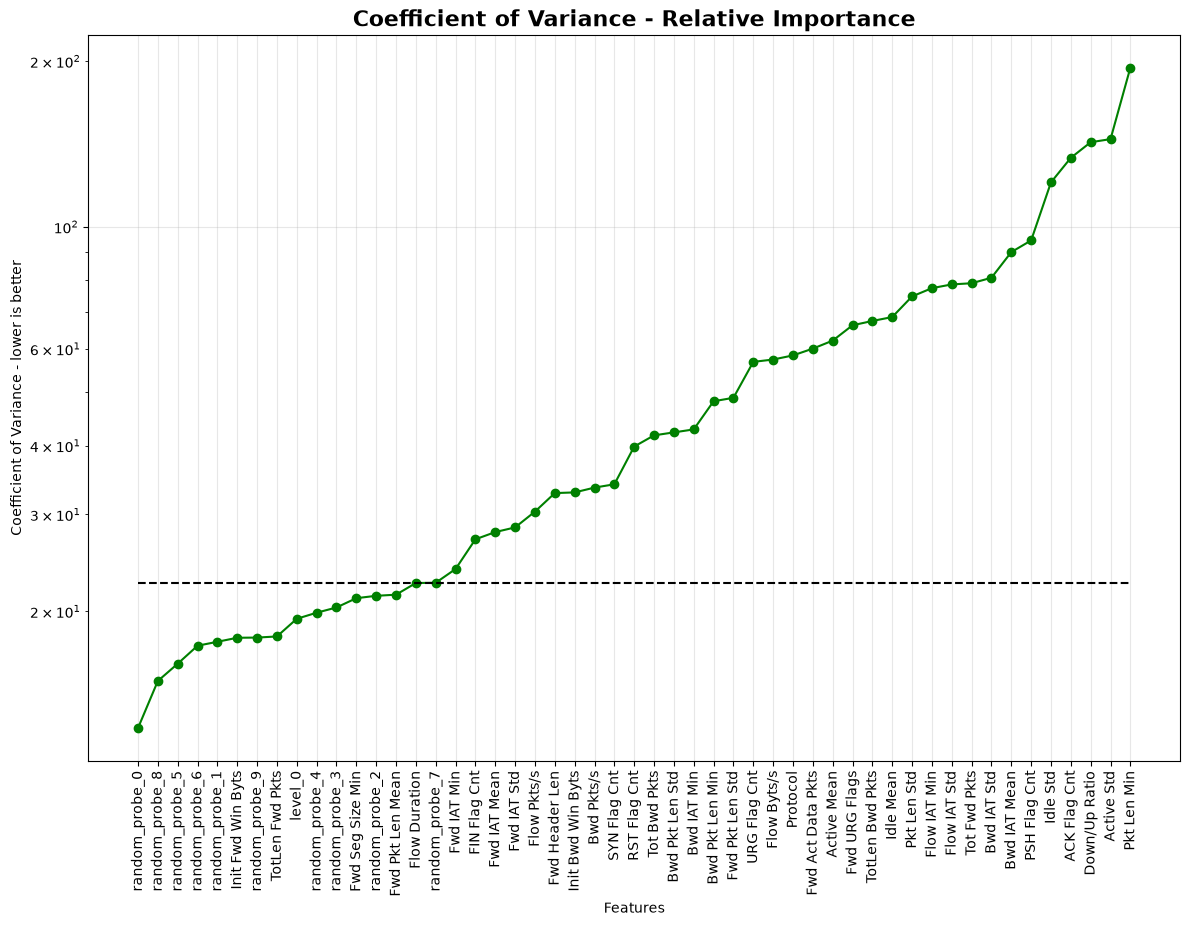

In [77]:
feature_importance(
    importance_cv_sorted,
    "Coefficient of Variance - Relative Importance",
    "Features",
    "Coefficient of Variance - lower is better",
    importance_cv_random
)

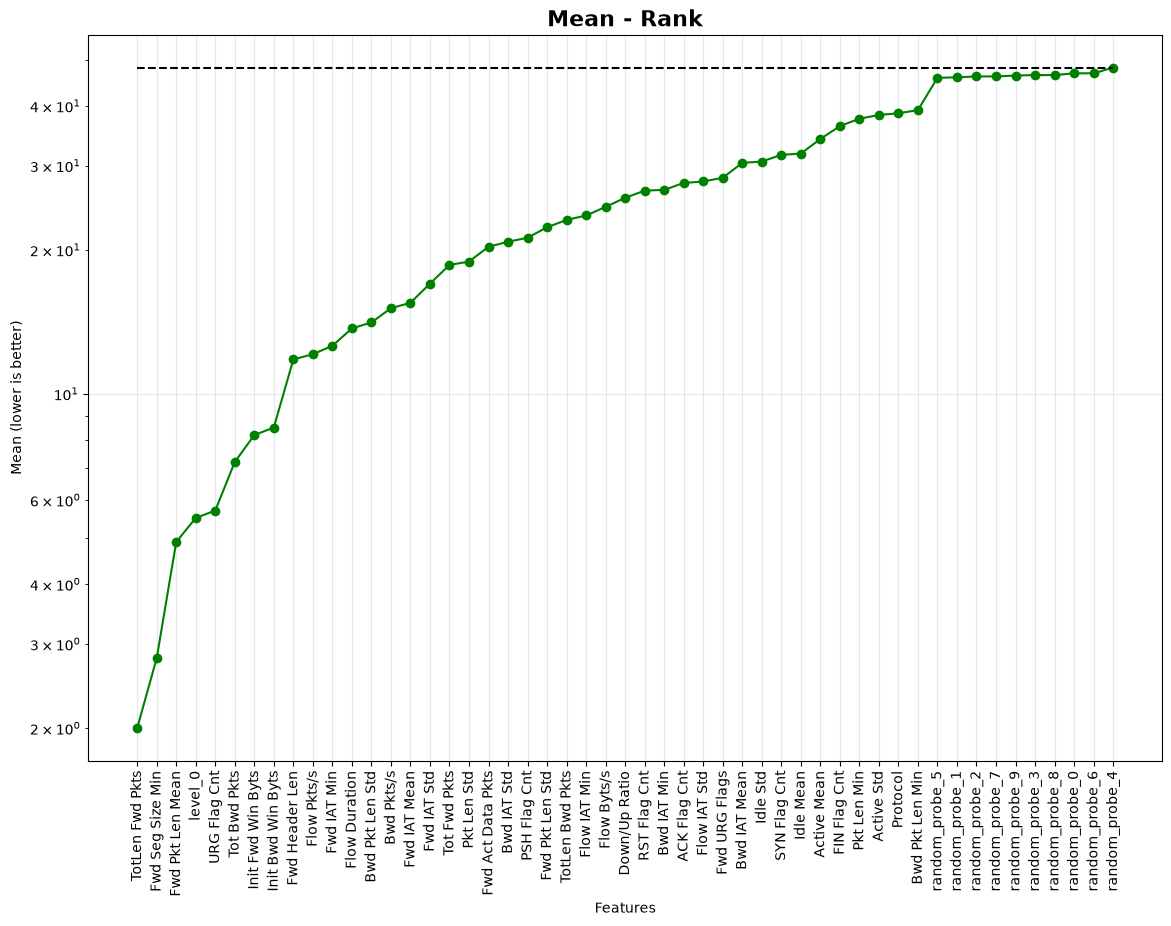

In [78]:
feature_importance(
    rank_mean_sorted,
    "Mean - Rank",
    "Features",
    "Mean (lower is better)",
    rank_mean_random
)

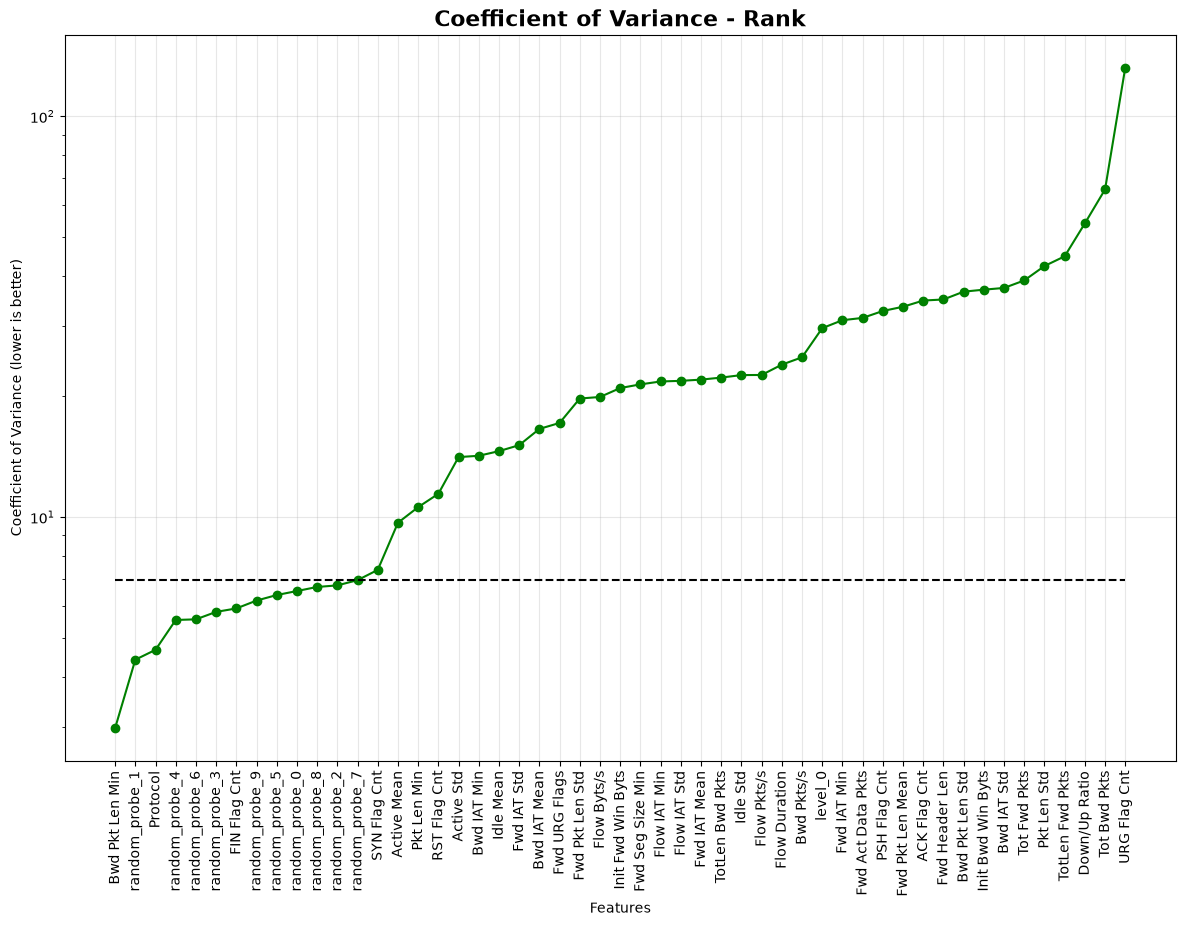

In [79]:
feature_importance(
    rank_cv_sorted,
    "Coefficient of Variance - Rank",
    "Features",
    "Coefficient of Variance (lower is better)",
    rank_cv_random
)

## Scatterplots

In [80]:
def boolMask(mean_value, cv_value, mean_threshold, cv_threshold):
    """
    Create a boolean mask for mean and coefficient of variation (CV) variables.
    Boolean mask slices a scatter plot into 4 quadrants:
        High mean low CVw
        High mean high CV
        Low mean low CV
        low mean high CV
    """
    high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv = [[] for x in range(4)]

    for mean, cv in zip(mean_value, cv_value):
        if (mean >= mean_threshold) & (cv < cv_threshold):
            high_mean_low_cv.append(True)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(False)
        elif (mean >= mean_threshold) & (cv >= cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(True)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(False)
        elif (mean < mean_threshold) & (cv < cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(True)
            low_mean_high_cv.append(False)
        elif (mean < mean_threshold) & (cv >= cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(True)

    return high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv

In [81]:
def scatterPlot(mean_values, cv_values, title, xlabel, ylabel, mean_threshold, cv_threshold):
    """
    Scatter plot between mean and coefficient of variation (CV)
    Scatter plots with 4 quadrants (described in a comment of boolMask function) are computed for 5 variables:
        Gain
        Weight
        Cover
        Relative Importance
        Rank
    """
    mean_values = np.array(list(mean_values))
    cv_values = np.array(list(cv_values))

    high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv = boolMask(mean_values, cv_values, mean_threshold, cv_threshold)

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.scatter(
        mean_values[high_mean_low_cv],
        cv_values[high_mean_low_cv],
        label="High mean / Low CV"
    )

    ax.scatter(
        mean_values[high_mean_high_cv],
        cv_values[high_mean_high_cv],
        label="High mean / High CV"
    )

    ax.scatter(
        mean_values[low_mean_low_cv],
        cv_values[low_mean_low_cv],
        label="Low mean / Low CV"
    )

    ax.scatter(
        mean_values[low_mean_high_cv],
        cv_values[low_mean_high_cv],
        label="Low mean / High CV"
    )

    # Threshold lines
    ax.axvline(
        mean_threshold,
        color="black",
        linestyle="--",
        alpha=0.3
    )

    ax.axhline(
        cv_threshold,
        color="black",
        linestyle="--",
        alpha=0.3
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")

    ax.legend()

    ax.grid(
        True,
        alpha=0.3
    )

    fig.savefig(f"images/{title}.png", bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

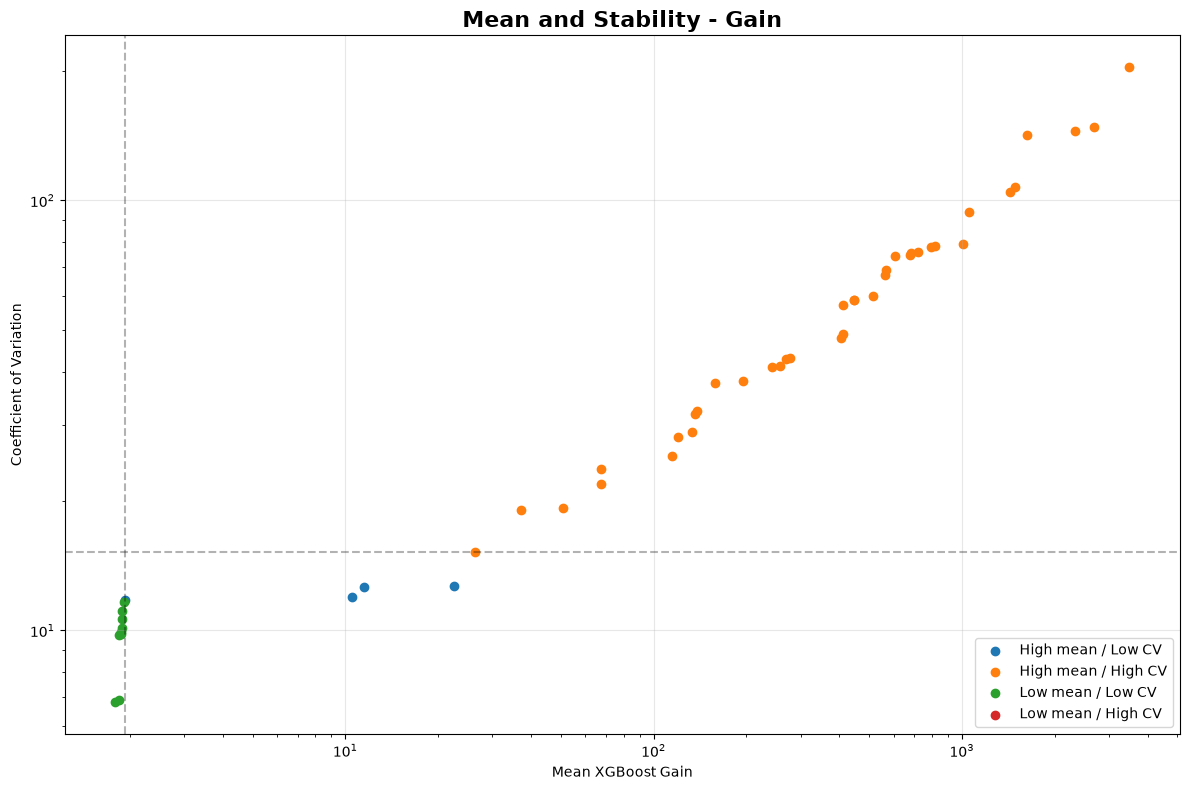

In [82]:
scatterPlot(
    gain_mean_sorted.values(),
    gain_cv_sorted.values(),
    "Mean and Stability - Gain",
    "Mean XGBoost Gain",
    "Coefficient of Variation",
    gain_mean_random,
    gain_cv_random
)

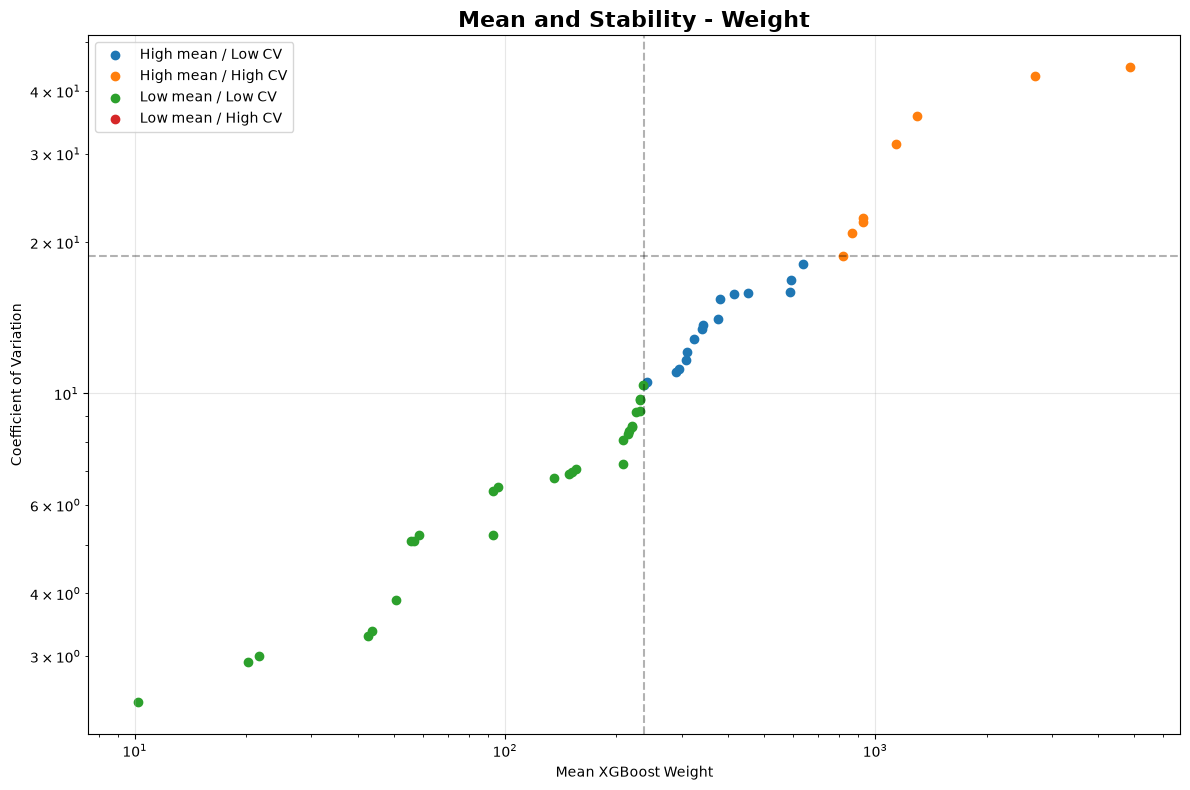

In [83]:
scatterPlot(
    weight_mean_sorted.values(),
    weight_cv_sorted.values(),
    "Mean and Stability - Weight",
    "Mean XGBoost Weight",
    "Coefficient of Variation",
    weight_mean_random,
    weight_cv_random
)

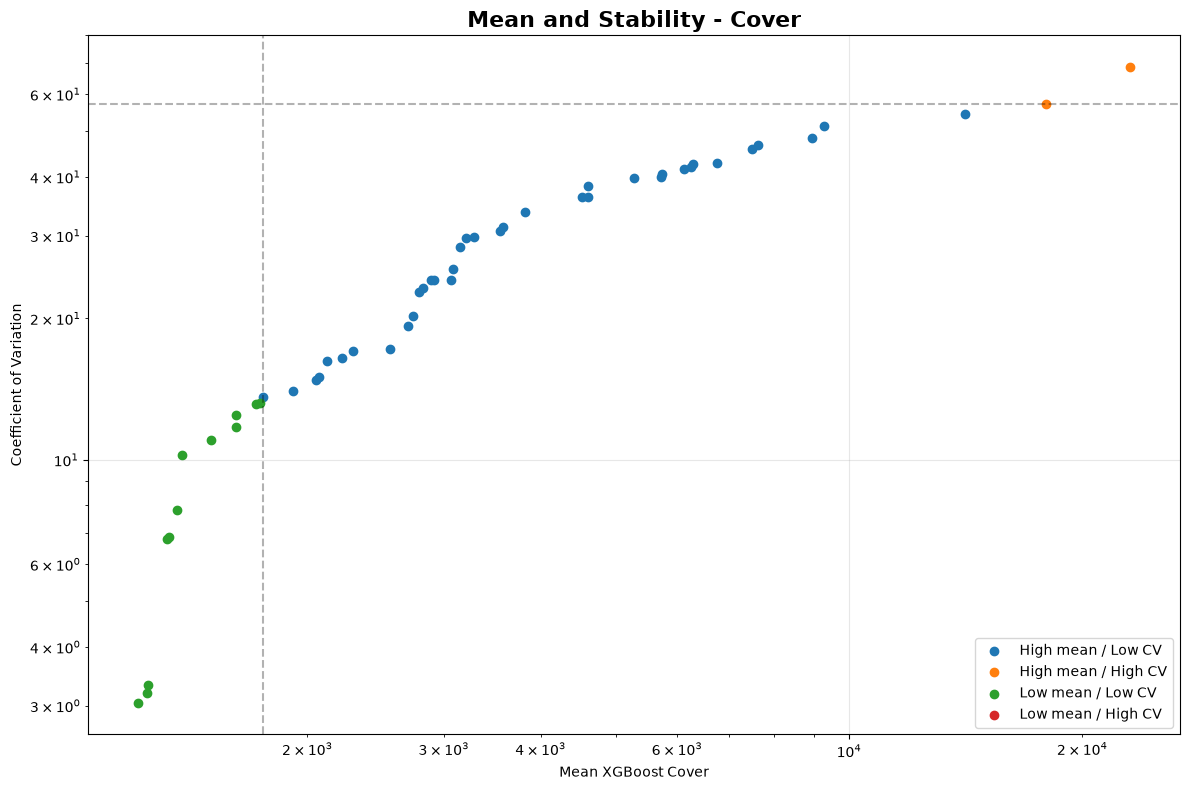

In [84]:
scatterPlot(
    cover_mean_sorted.values(),
    cover_cv_sorted.values(),
    "Mean and Stability - Cover",
    "Mean XGBoost Cover",
    "Coefficient of Variation",
    cover_mean_random,
    cover_cv_random
)

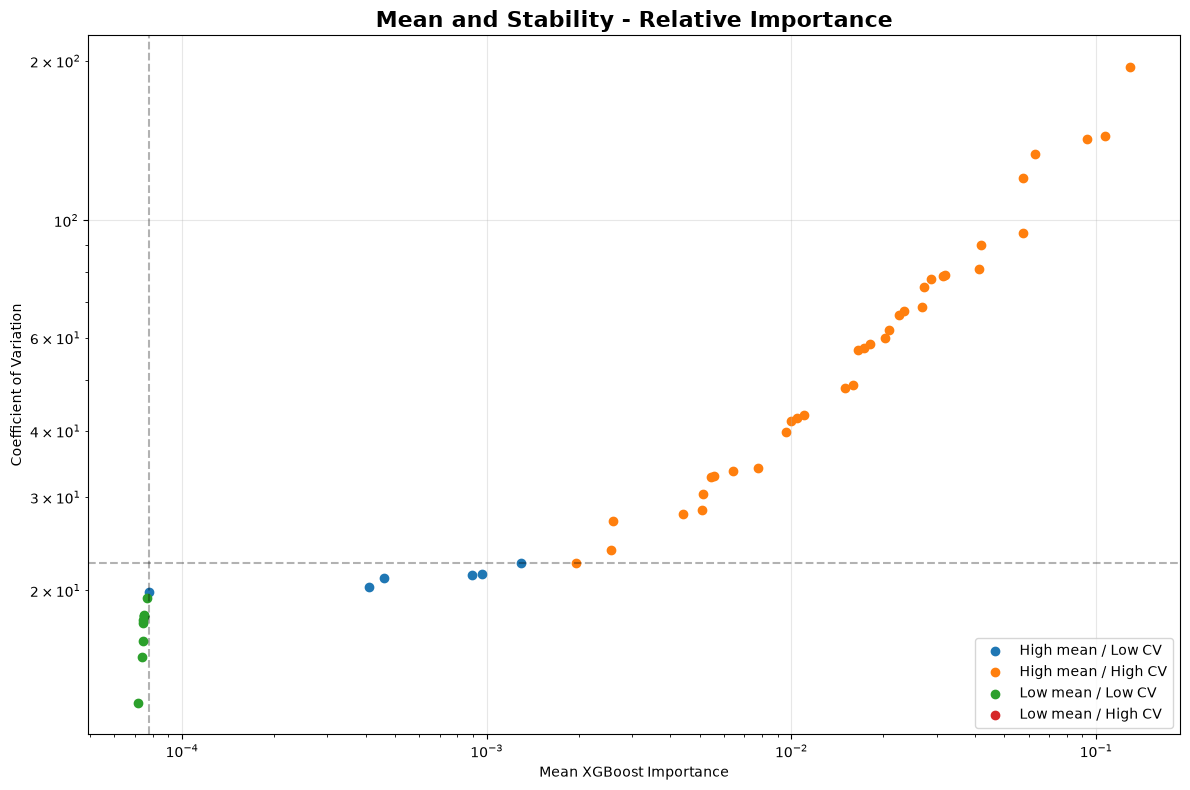

In [85]:
scatterPlot(
    importance_mean_sorted.values(),
    importance_cv_sorted.values(),
    "Mean and Stability - Relative Importance",
    "Mean XGBoost Importance",
    "Coefficient of Variation",
    importance_mean_random,
    importance_cv_random
)

## Exporting Descriptive Features

Parse high mean / low CV quadrant values for each parameter from scatterplots. Create a voting mechanism between them for keeping the features (favor gain, weight and cover)

In [86]:
features.drop(random_columns, axis=1, inplace=True)

In [87]:
gain_important_features = [
    feature for feature, mean, cv in zip(features.columns, gain_mean_sorted.values(), gain_cv_sorted.values()) if (mean >= gain_mean_random) and (cv < gain_cv_random)
]
weight_important_features = [
    feature for feature, mean, cv in zip(features.columns, weight_mean_sorted.values(), weight_cv_sorted.values()) if (mean >= weight_mean_random) and (cv < weight_cv_random)
]
cover_important_features = [
    feature for feature, mean, cv in zip(features.columns, cover_mean_sorted.values(), cover_cv_sorted.values()) if (mean >= cover_mean_random) and (cv < cover_cv_random)
]
importance_important_features = [
    feature for feature, mean, cv in zip(features.columns, importance_mean_sorted.values(), importance_cv_sorted.values()) if (mean >= importance_mean_random) and (cv < importance_cv_random)
]

In [88]:
gain_important_features

['Bwd Pkt Len Min', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s']

In [89]:
weight_important_features

['SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Idle Mean',
 'Idle Std']

In [90]:
cover_important_features

['Flow Pkts/s',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Min',
 'Fwd URG Flags',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Idle Mean',
 'Idle Std']

In [91]:
importance_important_features

['Bwd Pkt Len Min',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Std',
 'Flow IAT Min']

In [92]:
from collections import Counter

vote_counts = Counter()
for s in (gain_important_features, weight_important_features, cover_important_features, importance_important_features):
    vote_counts.update(s)

final_features = sorted(f for f, count in vote_counts.items() if count >= 2)

final_features

['ACK Flag Cnt',
 'Active Mean',
 'Active Std',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Std',
 'Down/Up Ratio',
 'Flow Byts/s',
 'Flow IAT Min',
 'Flow IAT Std',
 'Flow Pkts/s',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Idle Mean',
 'Idle Std',
 'Init Bwd Win Byts',
 'Init Fwd Win Byts',
 'PSH Flag Cnt',
 'RST Flag Cnt',
 'SYN Flag Cnt',
 'URG Flag Cnt']

Write dataframe with only final features to csv

In [93]:
df[final_features].to_csv("final.csv", encoding="utf-8", index=False)